In [1]:
import site
import sys

print(sys.executable)
print(site.getsitepackages())


e:\UK-Energy-Modelling-Update-main\UK-Energy-Modelling-Update-main\.venv\Scripts\python.exe
['e:\\UK-Energy-Modelling-Update-main\\UK-Energy-Modelling-Update-main\\.venv', 'e:\\UK-Energy-Modelling-Update-main\\UK-Energy-Modelling-Update-main\\.venv\\Lib\\site-packages']


In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import src.assumptions as A
import src.matplotlib_style  # noqa: F401
from src.data import renewable_capacity_factors
from src.demand_model import DemandMode, predicted_demand
from src.power_system import PowerSystem
from src.power_system_no_h2 import PowerSystemNoH2
from src.supply_model import daily_renewables_capacity
from src.units import Units as U


In [3]:
# ----------------------------
# Scenario configuration
# ----------------------------
REN_GW = 200
DAC_GW = 2
ENABLE_IMPORTS = False
CAPACITY_FACTORS_SOURCE = "era5_2024"
DEMAND_MODE = DemandMode.SEASONAL

HYDROGEN_STORAGE_TWH = A.HydrogenStorage.CavernStorage.Capacity
ELECTROLYSER_GW = A.HydrogenStorage.Electrolysis.Power
HYDROGEN_GEN_GW = A.HydrogenStorage.Generation.Power

OUTPUT_DIR = Path("nbs/output/h2_vs_no_h2")


In [4]:
# ----------------------------
# Build daily demand & supply
# ----------------------------
demand_df = predicted_demand(mode=DEMAND_MODE, historical="era5", filter_ldz=True)

daily_cf = renewable_capacity_factors.get_renewable_capacity_factors(
    source=CAPACITY_FACTORS_SOURCE,
    resample="D",
)
supply_df = pd.DataFrame(
    {REN_GW: daily_renewables_capacity(REN_GW * U.GW, daily_cf)},
    index=daily_cf.index,
)

common_idx = supply_df.index.intersection(demand_df.index)
supply_df = supply_df.reindex(common_idx)
demand_df = demand_df.reindex(common_idx)

net_supply_df = supply_df.sub(demand_df["demand"], axis=0)
net_supply_df = net_supply_df.rename(columns={REN_GW: f"S-D(TWh),Ren={REN_GW}GW"})

net_supply_df = net_supply_df.reset_index()
net_supply_df = net_supply_df.rename(columns={net_supply_df.columns[0]: "index"})


In [5]:
# ----------------------------
# Run simulations
# ----------------------------
ps_h2 = PowerSystem(
    renewable_capacity=REN_GW * U.GW,
    hydrogen_storage_capacity=HYDROGEN_STORAGE_TWH,
    electrolyser_power=ELECTROLYSER_GW,
    dac_capacity=DAC_GW * U.GW,
    hydrogen_generation_power=HYDROGEN_GEN_GW,
    enable_imports=ENABLE_IMPORTS,
    capacity_factors_source=CAPACITY_FACTORS_SOURCE,
    enable_gas_ltdac=True,


)

ps_no_h2 = PowerSystemNoH2(
    renewable_capacity=REN_GW * U.GW,
    dac_capacity=DAC_GW * U.GW,
    enable_imports=ENABLE_IMPORTS,
    capacity_factors_source=CAPACITY_FACTORS_SOURCE,
)

sim_h2 = ps_h2.run_simulation(net_supply_df)
sim_no_h2 = ps_no_h2.run_simulation(net_supply_df)

if sim_h2 is None or sim_no_h2 is None:
    failed = []
    if sim_h2 is None:
        failed.append("with_h2")
    if sim_no_h2 is None:
        failed.append("no_h2")
    print(f"Simulation failed for: {', '.join(failed)}. Try increasing REN_GW or storage, or enabling imports.")
    # Stop further analysis cells if any scenario failed.
    # You can adjust parameters above and re-run this cell.
    raise SystemExit

    raise RuntimeError("Simulation failed for at least one scenario; increase storage or renewable capacity.")

analysis_h2 = ps_h2.analyze_simulation_results(sim_h2)
analysis_no_h2 = ps_no_h2.analyze_simulation_results(sim_no_h2)


In [6]:
# Align simulation outputs to the original date index for resampling/plotting
sim_h2.index = net_supply_df.index
sim_no_h2.index = net_supply_df.index


In [7]:
# ----------------------------
# Summary table
# ----------------------------
def _to_value(value):
    return value.magnitude if hasattr(value, "magnitude") else value


summary = pd.DataFrame(
    {
        "with_h2": analysis_h2,
        "no_h2": analysis_no_h2,
    }
).map(_to_value)

summary.loc["total_system_cost_GBP", "with_h2"] = _to_value(ps_h2.calculate_power_system_cost(sim_h2))
summary.loc["total_system_cost_GBP", "no_h2"] = _to_value(ps_no_h2.calculate_power_system_cost(sim_no_h2))

units = {
    "minimum_medium_storage": "TWh",
    "minimum_hydrogen_storage": "TWh",
    "annual_dac_energy": "TWh",
    "annual_co2_removals": "MtCO2",
    "dac_capacity_factor": "%",
    "curtailed_energy": "TWh",
    "annual_gas_ccs_energy": "TWh",
    "annual_gas_co2_production": "MtCO2",
    "gas_ccs_capacity_factor": "%",
    "annual_interconnect_energy": "TWh",
    "annual_gas_dac_electricity": "TWh",
    "annual_gas_dac_capture": "MtCO2",
    "total_system_cost_GBP": "GBP",
}

summary.index = [
    f"{k} [{units.get(k, "")}]" if units.get(k) else k
    for k in summary.index
]

summary

,with_h2,no_h2
minimum_medium_storage [TWh],0.000000e+00,0.000000e+00
minimum_hydrogen_storage [TWh],9.756488e+01,NaN
annual_dac_energy [TWh],5.883190e+00,9.555378e+00
annual_co2_removals [MtCO2],9.228802e+00,1.498927e+01
dac_capacity_factor [%],3.432218e-01,5.605666e-01
curtailed_energy [TWh],6.385099e+01,9.446536e+01
annual_gas_ccs_energy [TWh],3.384798e+01,5.822019e+01
gas_ccs_capacity_factor [%],3.148260e-01,3.148260e-01
annual_interconnect_energy [TWh],0.000000e+00,0.000000e+00
annual_gas_dac_electricity [TWh],7.304337e+00,1.033380e+01


In [8]:
# Save summary table (optional)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(OUTPUT_DIR / "summary_h2_vs_no_h2.csv")


In [9]:
# ----------------------------
# Plot helpers
# ----------------------------
def _col(sim_df: pd.DataFrame, name: str) -> pd.Series:
    col = f"{name} (TWh),RC={REN_GW}GW"
    return pd.Series(sim_df[col].pint.magnitude, index=sim_df.index)


def _plot_two_series(ax, s1: pd.Series, s2: pd.Series, label1: str, label2: str, title: str, ylabel: str) -> None:
    ax.plot(s1, label=label1, linewidth=0.8)
    ax.plot(s2, label=label2, linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(loc="upper right", fontsize=9, frameon=True)


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_42424\3346564014.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


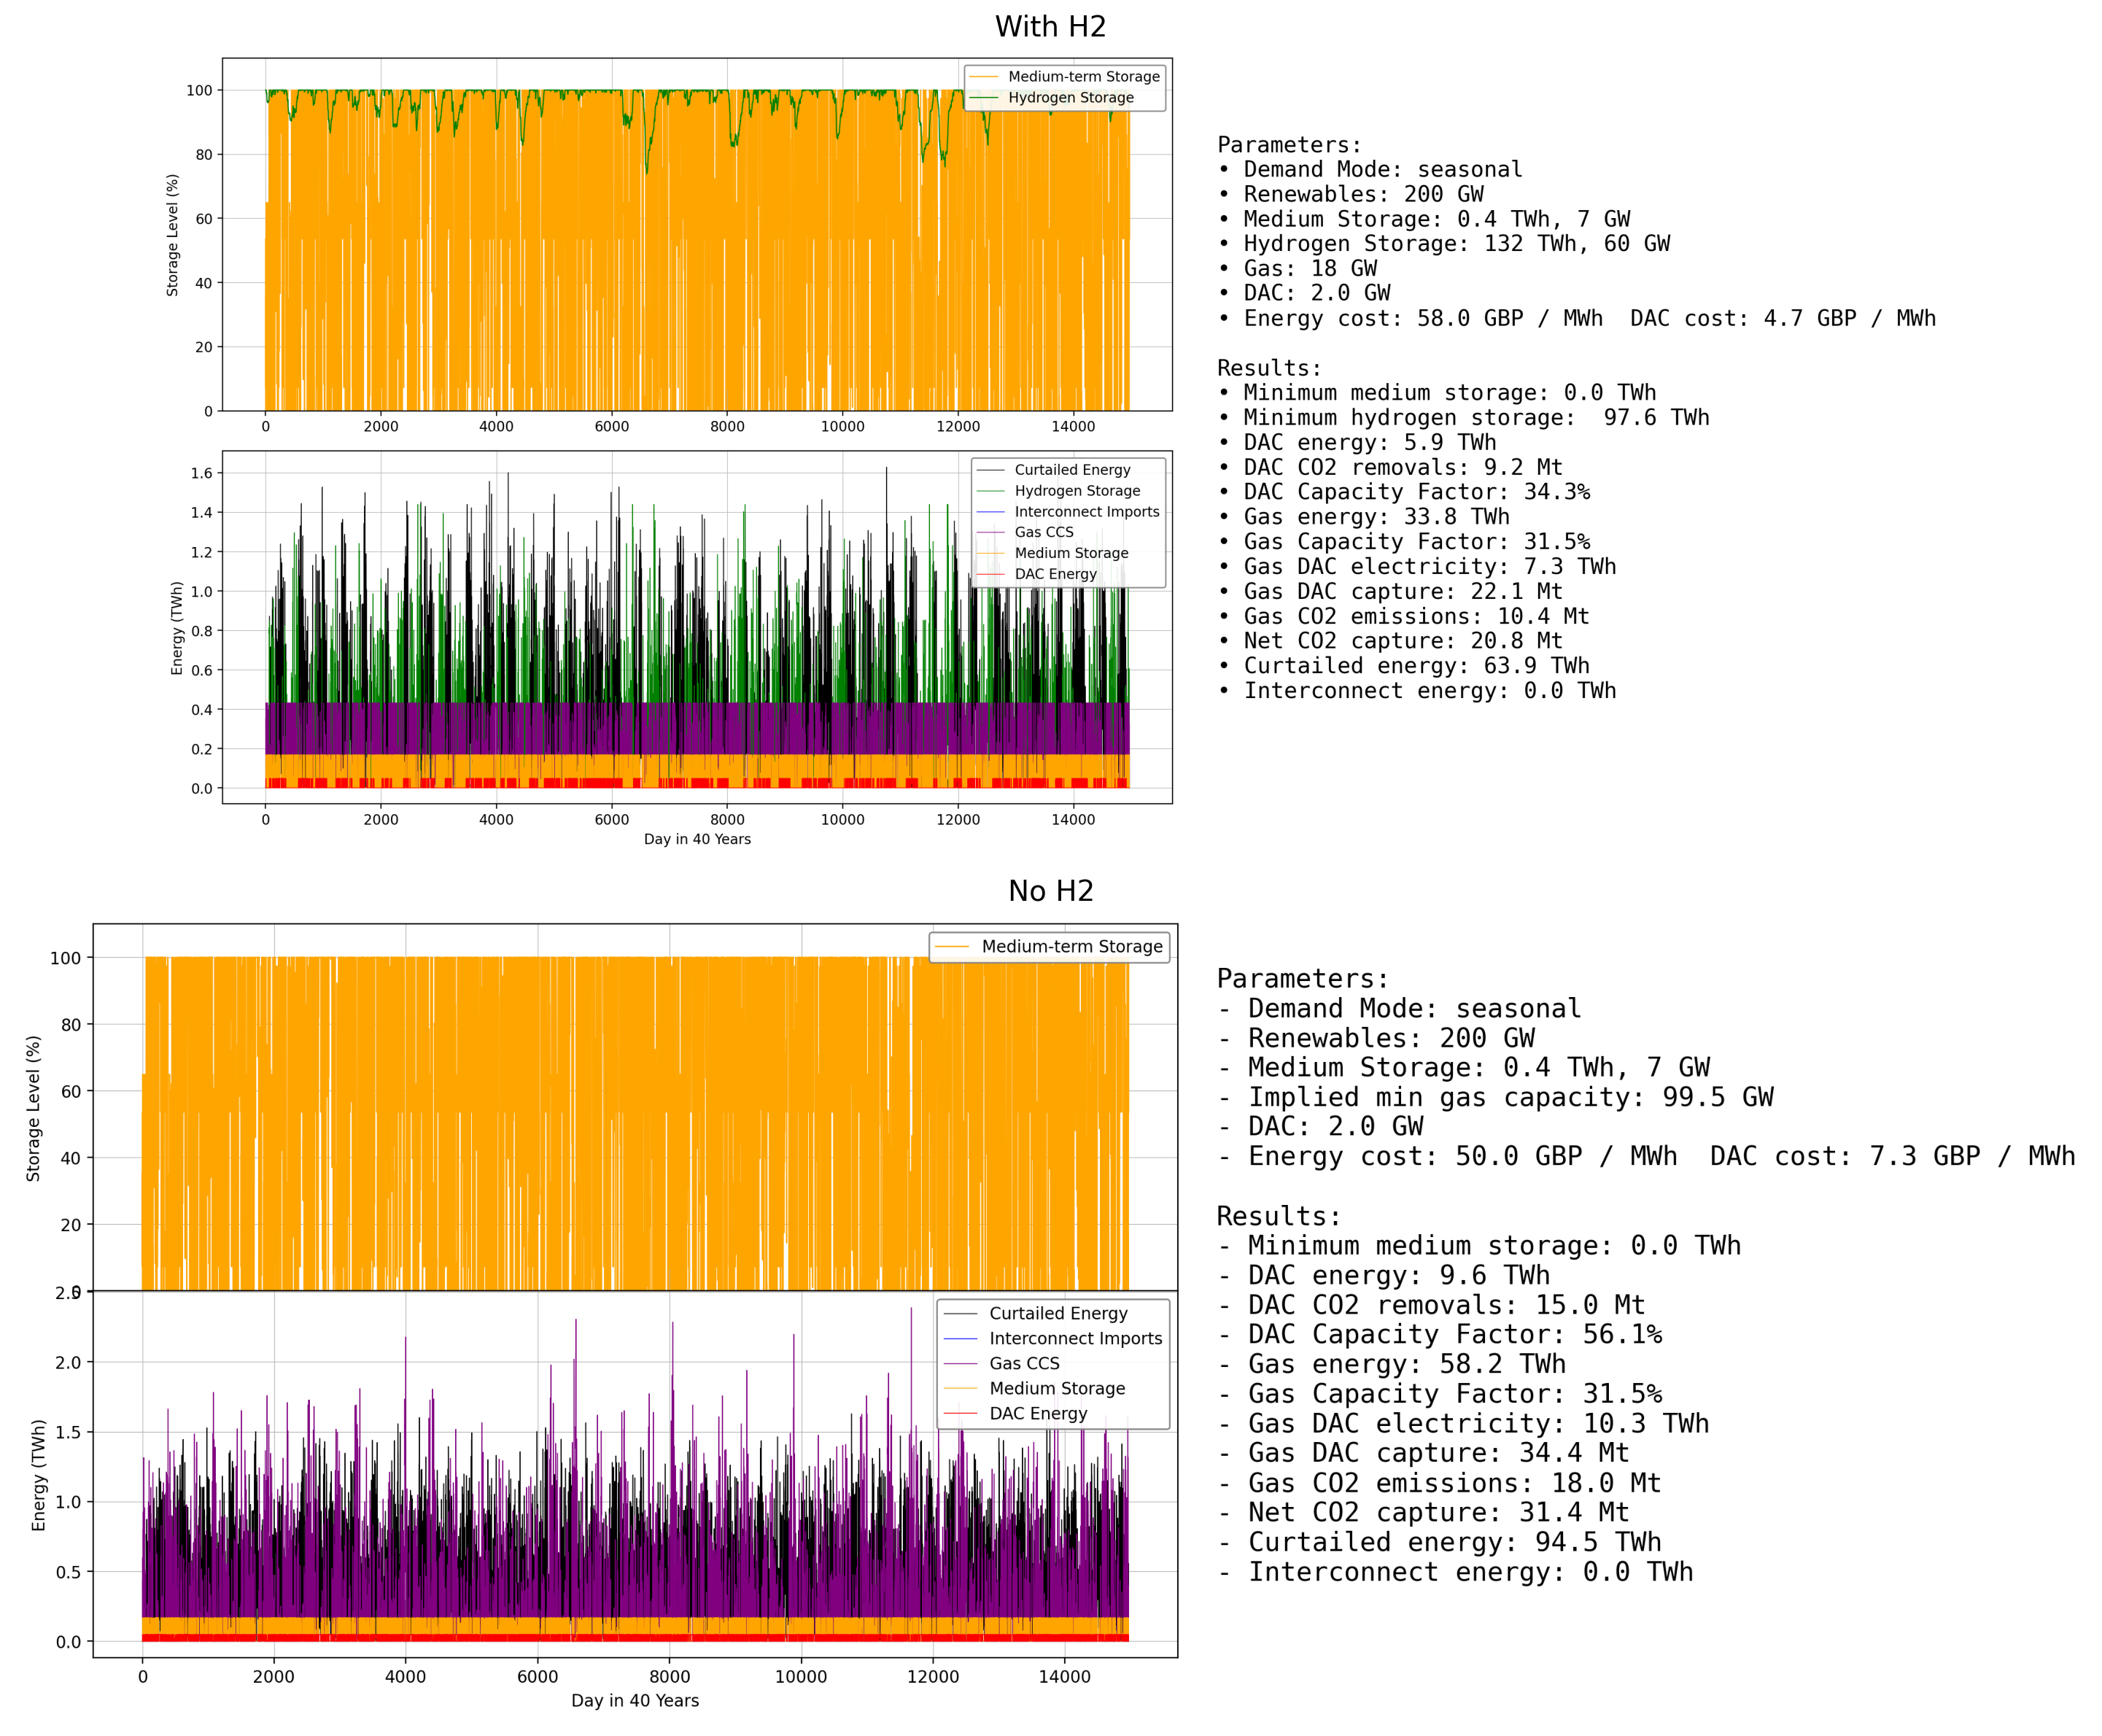

In [10]:
# Side-by-side plots for with H2 and no H2 using plot_simulation_results
# (renders each plot to file, then displays them together)

from pathlib import Path

import matplotlib.image as mpimg

# make sure output dir exists
OUTPUT_DIR = Path("nbs/output/h2_vs_no_h2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1) save each plot to a file
plot_h2_path = OUTPUT_DIR / "plot_with_h2.png"
plot_no_h2_path = OUTPUT_DIR / "plot_no_h2.png"

# with H2
ps_h2.plot_simulation_results(sim_h2, analysis_h2, DEMAND_MODE)
fig_h2 = plt.gcf()
fig_h2.savefig(plot_h2_path, dpi=200, bbox_inches="tight")
plt.close(fig_h2)

# no H2
ps_no_h2.plot_simulation_results(sim_no_h2, analysis_no_h2, DEMAND_MODE)
fig_no = plt.gcf()
fig_no.savefig(plot_no_h2_path, dpi=200, bbox_inches="tight")
plt.close(fig_no)


# 2) show them side-by-side
img_h2 = mpimg.imread(plot_h2_path)
img_no = mpimg.imread(plot_no_h2_path)

fig, axes = plt.subplots(2, 1, figsize=(18, 12), dpi=200)

axes[0].imshow(img_h2)
axes[0].set_title("With H2", fontsize=14)
axes[0].axis("off")

axes[1].imshow(img_no)
axes[1].set_title("No H2", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [11]:
# ----------------------------
# Annual totals comparison
# ----------------------------
annual = pd.DataFrame(
    {
        "with_h2": {
            "curtailed_energy_TWh": _col(sim_h2, "curtailed_energy").mean() * 365,
            "dac_energy_TWh": _col(sim_h2, "dac_energy").mean() * 365,
            "gas_ccs_energy_TWh": _col(sim_h2, "gas_ccs_energy").mean() * 365,
            "interconnect_energy_TWh": _col(sim_h2, "interconnect_energy").mean() * 365,
        },
        "no_h2": {
            "curtailed_energy_TWh": _col(sim_no_h2, "curtailed_energy").mean() * 365,
            "dac_energy_TWh": _col(sim_no_h2, "dac_energy").mean() * 365,
            "gas_ccs_energy_TWh": _col(sim_no_h2, "gas_ccs_energy").mean() * 365,
            "interconnect_energy_TWh": _col(sim_no_h2, "interconnect_energy").mean() * 365,
            "gas_dac_electricity_TWh": _col(sim_no_h2, "gas_dac_electricity").mean() * 365,
            "gas_dac_capture_Mt": pd.Series(
                sim_no_h2[f"gas_dac_capture (MtCO2),RC={REN_GW}GW"].pint.magnitude,
                index=sim_no_h2.index,
            ).mean()
            * 365,
        },
    }
)

annual


,with_h2,no_h2
curtailed_energy_TWh,63.850993,94.465362
dac_energy_TWh,5.883190,9.555378
gas_ccs_energy_TWh,33.847981,58.220189
interconnect_energy_TWh,0.000000,0.000000
gas_dac_electricity_TWh,NaN,10.333801
gas_dac_capture_Mt,NaN,34.401416


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_42424\3792293531.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


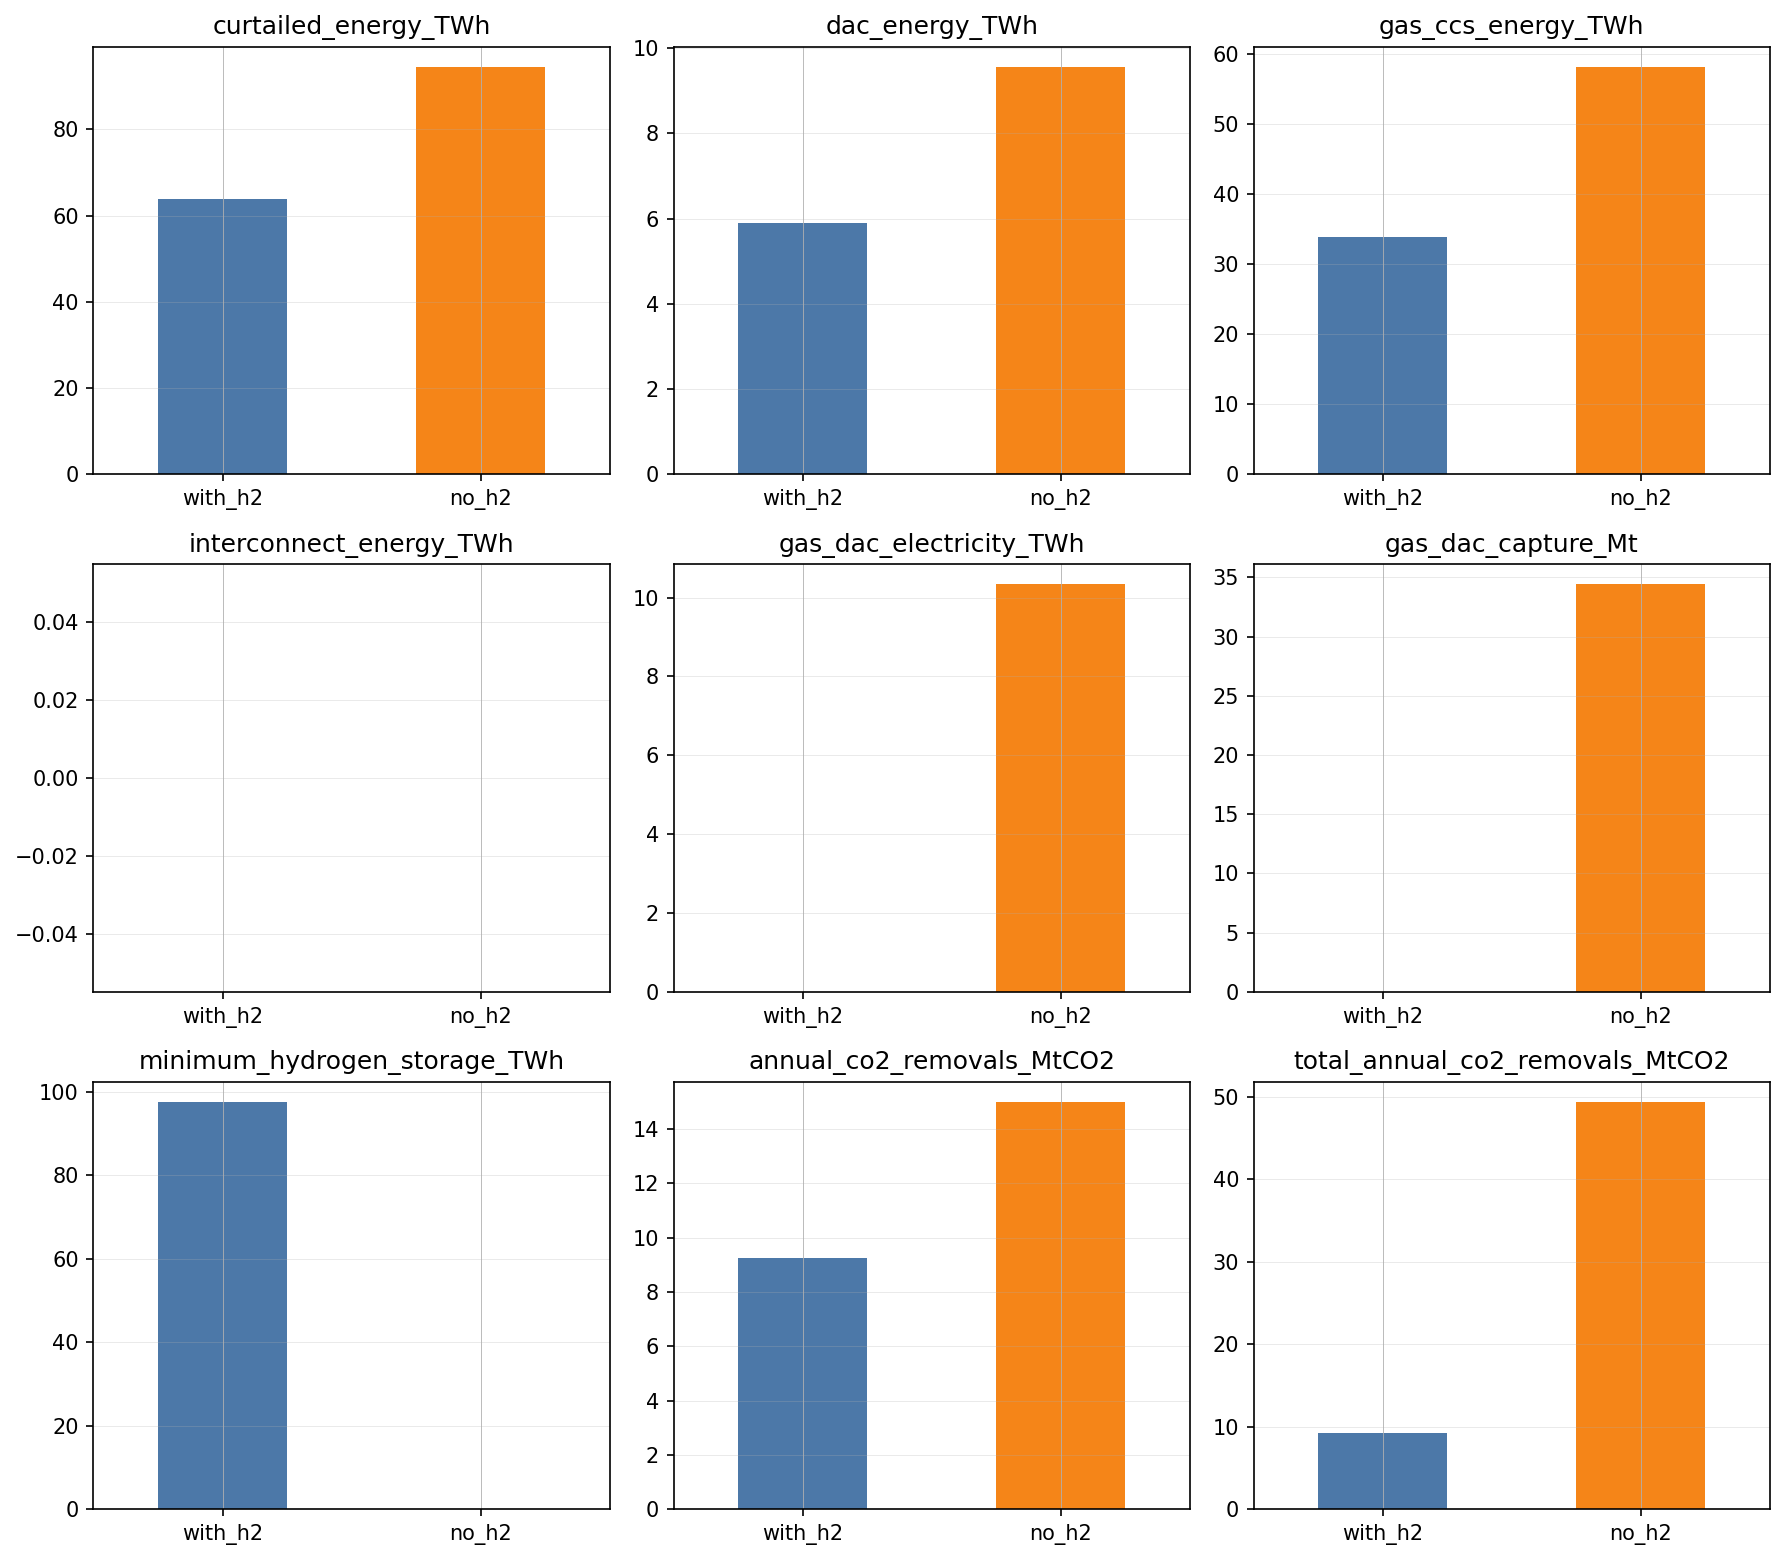

In [12]:
import matplotlib.pyplot as plt
import numpy as np

from src.units import Units as U


def _to_value(value):
    return value.magnitude if hasattr(value, "magnitude") else value


# annual FROM analysis
if "annual" not in globals():
    summary = pd.DataFrame({"with_h2": analysis_h2, "no_h2": analysis_no_h2}).map(_to_value)
    annual = summary
else:
    annual = annual.copy()

# with_h2 ：minimum_hydrogen_storage
if "minimum_hydrogen_storage" in analysis_h2:
    annual.loc["minimum_hydrogen_storage_TWh"] = [
        analysis_h2["minimum_hydrogen_storage"].to(U.TWh).magnitude,
        np.nan,
    ]

# DAC CO2 removals
if "annual_co2_removals" in analysis_h2 and "annual_co2_removals" in analysis_no_h2:
    annual.loc["annual_co2_removals_MtCO2"] = [
        analysis_h2["annual_co2_removals"].to(U.Mt).magnitude,
        analysis_no_h2["annual_co2_removals"].to(U.Mt).magnitude,
    ]

# total annual CO2 removals (with_h2 = DAC only; no_h2 = DAC + gas DAC)
annual.loc["total_annual_co2_removals_MtCO2"] = [
    analysis_h2["annual_co2_removals"].to(U.Mt).magnitude,
    (
        analysis_no_h2["annual_co2_removals"]
        + analysis_no_h2.get("annual_gas_dac_capture", 0 * U.Mt)
    ).to(U.Mt).magnitude,
]

# MAKE PLOTS
metrics = annual.index.tolist()
ncols = 3
nrows = int(np.ceil(len(metrics) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows), dpi=150)
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    annual.loc[metric].plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518"])
    ax.set_title(metric)
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.grid(axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


140 with_h2 None | no_h2 61.75082176205223
150 with_h2 None | no_h2 58.38410850702742
160 with_h2 None | no_h2 55.65792682109639
170 with_h2 None | no_h2 53.533916019826385
180 with_h2 None | no_h2 51.93967067205109
190 with_h2 54.12903468123334 | no_h2 50.784892903014374
200 with_h2 54.23306586052023 | no_h2 49.99910842380325
210 with_h2 54.47357294931368 | no_h2 49.52093752300099
220 with_h2 54.835134837029884 | no_h2 49.305472193389114
230 with_h2 55.29865508555055 | no_h2 49.30194112293569
240 with_h2 55.83953522656927 | no_h2 49.468056580212874
250 with_h2 56.4628175609911 | no_h2 49.78761376555007
260 with_h2 57.15572105271996 | no_h2 50.22664133523582
270 with_h2 57.907641674682054 | no_h2 50.7723853423357
280 with_h2 58.712929014284505 | no_h2 51.40763752549721
290 with_h2 59.56236258520816 | no_h2 52.11656330238419
300 with_h2 60.45564677686393 | no_h2 52.88971657775647
310 with_h2 61.38444070743015 | no_h2 53.71871879913518
320 with_h2 62.345560885138944 | no_h2 54.5959397975

C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_42424\1655272132.py:77: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


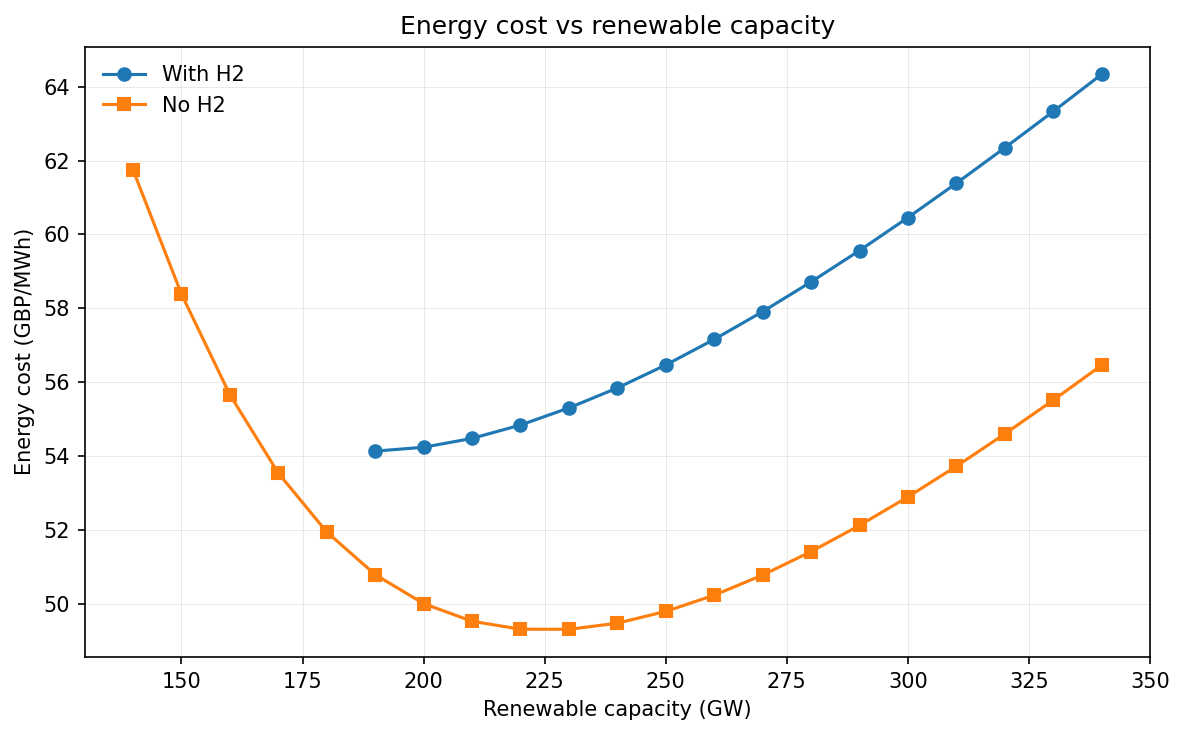

In [13]:


# ----- settings -----
DEMAND_MODE = DemandMode.SEASONAL
ENABLE_IMPORTS = False
REN_RANGE = range(140, 350, 10)

# demand + capacity factors
demand_df = predicted_demand(mode=DEMAND_MODE, average_year=False)
daily_cf = renewable_capacity_factors.get_renewable_capacity_factors(
    source="era5_2024", resample="D"
)


def build_net_supply_df(ren_gw: int) -> pd.DataFrame:
    supply = daily_renewables_capacity(ren_gw * U.GW, daily_cf)
    common_idx = supply.index.intersection(demand_df.index)
    supply = supply.reindex(common_idx)
    demand = demand_df.reindex(common_idx)
    net_supply_df = (supply - demand["demand"]).to_frame(name=f"S-D(TWh),Ren={ren_gw}GW")
    return net_supply_df.reset_index()


def energy_cost_with_h2(ren_gw: int) -> float | None:
    df = build_net_supply_df(ren_gw)
    ps = PowerSystem(
        renewable_capacity=ren_gw * U.GW,
        hydrogen_storage_capacity=50 * U.TWh,
        electrolyser_power=A.HydrogenStorage.Electrolysis.Power,
        dac_capacity=2 * U.GW,
        hydrogen_generation_power=A.HydrogenStorage.Generation.Power,
        only_dac_if_hydrogen_storage_full=False,
        medium_storage_capacity=A.MediumTermStorage.Capacity,
        medium_storage_power=A.MediumTermStorage.Power,
        enable_gas_ltdac=True,
        enable_imports=ENABLE_IMPORTS,
        capacity_factors_source="era5_2024",
    )
    sim = ps.run_simulation(df)
    if sim is None:
        return None
    total_cost = ps.calculate_power_system_cost(sim)
    return (total_cost / A.EnergyDemand2050).to(U.GBP / U.MWh).magnitude


def energy_cost_no_h2(ren_gw: int) -> float | None:
    df = build_net_supply_df(ren_gw)
    ps = PowerSystemNoH2(
        renewable_capacity=ren_gw * U.GW,
        dac_capacity=2 * U.GW,
        medium_storage_capacity=A.MediumTermStorage.Capacity,
        medium_storage_power=A.MediumTermStorage.Power,
        enable_imports=ENABLE_IMPORTS,
        capacity_factors_source="era5_2024",
    )
    sim = ps.run_simulation(df)
    if sim is None:
        return None
    total_cost = ps.calculate_power_system_cost(sim)
    return (total_cost / A.EnergyDemand2050).to(U.GBP / U.MWh).magnitude


# scan
ren_list = list(REN_RANGE)
cost_h2, cost_no_h2 = [], []

for ren in ren_list:
    c1 = energy_cost_with_h2(ren)
    c2 = energy_cost_no_h2(ren)
    cost_h2.append(c1)
    cost_no_h2.append(c2)
    print(ren, "with_h2", c1, "| no_h2", c2)

# plot
plt.figure(figsize=(8, 5))
plt.plot(ren_list, cost_h2, marker="o", label="With H2")
plt.plot(ren_list, cost_no_h2, marker="s", label="No H2")
plt.xlabel("Renewable capacity (GW)")
plt.ylabel("Energy cost (GBP/MWh)")
plt.title("Energy cost vs renewable capacity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_42424\1493541153.py:99: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


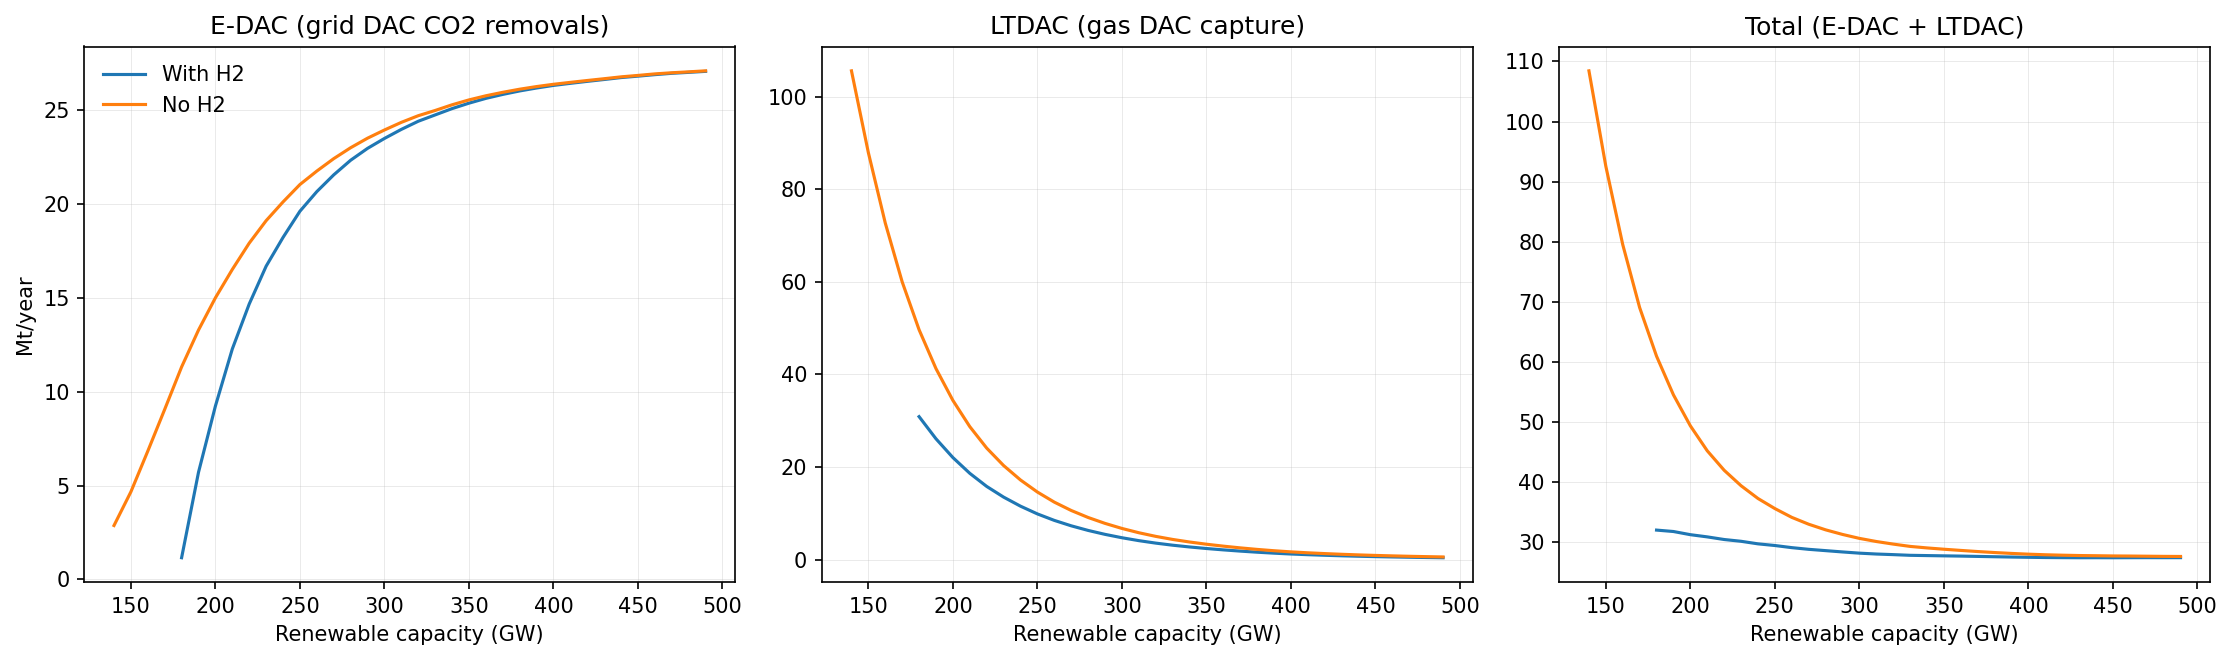

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REN_GW_LIST = list(range(140, 500, 10))

rows = []
for ren_gw in REN_GW_LIST:
    # build net supply
    supply_df = pd.DataFrame(
        {ren_gw: daily_renewables_capacity(ren_gw * U.GW, daily_cf)},
        index=daily_cf.index,
    )
    common_idx = supply_df.index.intersection(demand_df.index)
    supply_df = supply_df.reindex(common_idx)
    demand_aligned = demand_df.reindex(common_idx)

    net_supply_df = supply_df.sub(demand_aligned["demand"], axis=0)
    net_supply_df = net_supply_df.rename(columns={ren_gw: f"S-D(TWh),Ren={ren_gw}GW"})
    net_supply_df = net_supply_df.copy()
    net_supply_df["index"] = net_supply_df.index

    # with H2
    ps_h2 = PowerSystem(
        renewable_capacity=ren_gw * U.GW,
        hydrogen_storage_capacity=HYDROGEN_STORAGE_TWH,
        electrolyser_power=ELECTROLYSER_GW,
        dac_capacity=DAC_GW * U.GW,
        hydrogen_generation_power=HYDROGEN_GEN_GW,
        enable_imports=ENABLE_IMPORTS,
        capacity_factors_source=CAPACITY_FACTORS_SOURCE,
        enable_gas_ltdac=True,

    )
    sim_h2 = ps_h2.run_simulation(net_supply_df)
    if sim_h2 is None:
        e_dac_h2 = ltdac_h2 = total_h2 = np.nan
    else:
        analysis_h2 = ps_h2.analyze_simulation_results(sim_h2)
        e_dac_h2 = analysis_h2["annual_co2_removals"].to(U.Mt).magnitude  # grid DAC
        ltdac_h2 = analysis_h2.get("annual_gas_dac_capture", 0 * U.Mt).to(U.Mt).magnitude  # gas DAC
        total_h2 = e_dac_h2 + ltdac_h2

    # no H2
    ps_no_h2 = PowerSystemNoH2(
        renewable_capacity=ren_gw * U.GW,
        dac_capacity=DAC_GW * U.GW,
        enable_imports=ENABLE_IMPORTS,
        capacity_factors_source=CAPACITY_FACTORS_SOURCE,
    )
    sim_no_h2 = ps_no_h2.run_simulation(net_supply_df)
    if sim_no_h2 is None:
        e_dac_no = ltdac_no = total_no = np.nan
    else:
        analysis_no = ps_no_h2.analyze_simulation_results(sim_no_h2)
        e_dac_no = analysis_no["annual_co2_removals"].to(U.Mt).magnitude  # grid DAC
        ltdac_no = analysis_no.get("annual_gas_dac_capture", 0 * U.Mt).to(U.Mt).magnitude  # gas DAC
        total_no = e_dac_no + ltdac_no

    rows.append(
        {
            "ren_gw": ren_gw,
            "e_dac_with_h2": e_dac_h2,
            "ltdac_with_h2": ltdac_h2,
            "total_with_h2": total_h2,
            "e_dac_no_h2": e_dac_no,
            "ltdac_no_h2": ltdac_no,
            "total_no_h2": total_no,
        }
    )

df_capture = pd.DataFrame(rows).set_index("ren_gw")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150, sharex=True)

axes[0].plot(df_capture.index, df_capture["e_dac_with_h2"], label="With H2")
axes[0].plot(df_capture.index, df_capture["e_dac_no_h2"], label="No H2")
axes[0].set_title("E-DAC (grid DAC CO2 removals)")
axes[0].set_ylabel("Mt/year")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_capture.index, df_capture["ltdac_with_h2"], label="With H2")
axes[1].plot(df_capture.index, df_capture["ltdac_no_h2"], label="No H2")
axes[1].set_title("LTDAC (gas DAC capture)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_capture.index, df_capture["total_with_h2"], label="With H2")
axes[2].plot(df_capture.index, df_capture["total_no_h2"], label="No H2")
axes[2].set_title("Total (E-DAC + LTDAC)")
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlabel("Renewable capacity (GW)")


axes[0].legend(loc="best")
plt.tight_layout()
plt.show()


In [15]:
import numpy as np
import plotly.graph_objects as go

# sweep ranges
REN_GW_LIST = list(range(140, 300, 10))
DAC_GW_LIST = list(range(0, 11, 1))  # grid DAC capacity sweep (GW)

# Z[dac_index, ren_index] = annual E-DAC capture (Mt/yr)
Z = np.full((len(DAC_GW_LIST), len(REN_GW_LIST)), np.nan)

for i, dac_gw in enumerate(DAC_GW_LIST):
    for j, ren_gw in enumerate(REN_GW_LIST):
        df = build_net_supply_df(ren_gw)

        ps = PowerSystemNoH2(
            renewable_capacity=ren_gw * U.GW,
            dac_capacity=dac_gw * U.GW,
            medium_storage_capacity=A.MediumTermStorage.Capacity,
            medium_storage_power=A.MediumTermStorage.Power,
            enable_imports=ENABLE_IMPORTS,
            capacity_factors_source=CAPACITY_FACTORS_SOURCE,
        )
        sim = ps.run_simulation(df)
        if sim is None:
            continue
        analysis = ps.analyze_simulation_results(sim)
        Z[i, j] = analysis["annual_co2_removals"].to(U.Mt).magnitude  # E-DAC (grid DAC)

# meshgrid for plotly surface
X, Y = np.meshgrid(REN_GW_LIST, DAC_GW_LIST)

fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z,
            colorscale="Viridis",
        )
    ]
)

fig.update_layout(
    title="E-DAC capture vs renewable capacity and DAC capacity",
    scene=dict(
        xaxis_title="Renewable Capacity (GW)",
        yaxis_title="Grid DAC Capacity (GW)",
        zaxis_title="E-DAC Capture (Mt/yr)",
    ),
    width=800,
    height=600,
)

fig.show()


In [16]:
import numpy as np
import plotly.graph_objects as go

# sweep ranges
REN_GW_LIST = list(range(140, 300, 10))
DAC_GW_LIST = list(range(0, 11, 1))

# Z surfaces
Z_no = np.full((len(DAC_GW_LIST), len(REN_GW_LIST)), np.nan)
Z_h2 = np.full((len(DAC_GW_LIST), len(REN_GW_LIST)), np.nan)

for i, dac_gw in enumerate(DAC_GW_LIST):
    for j, ren_gw in enumerate(REN_GW_LIST):
        df = build_net_supply_df(ren_gw)

        # no H2
        ps_no = PowerSystemNoH2(
            renewable_capacity=ren_gw * U.GW,
            dac_capacity=dac_gw * U.GW,
            medium_storage_capacity=A.MediumTermStorage.Capacity,
            medium_storage_power=A.MediumTermStorage.Power,
            enable_imports=ENABLE_IMPORTS,
            capacity_factors_source=CAPACITY_FACTORS_SOURCE,
        )
        sim_no = ps_no.run_simulation(df)
        if sim_no is not None:
            analysis_no = ps_no.analyze_simulation_results(sim_no)
            Z_no[i, j] = analysis_no["annual_co2_removals"].to(U.Mt).magnitude

        # with H2
        ps_h2 = PowerSystem(
            renewable_capacity=ren_gw * U.GW,
            hydrogen_storage_capacity=HYDROGEN_STORAGE_TWH,
            electrolyser_power=ELECTROLYSER_GW,
            dac_capacity=dac_gw * U.GW,
            hydrogen_generation_power=HYDROGEN_GEN_GW,
            enable_imports=ENABLE_IMPORTS,
            capacity_factors_source=CAPACITY_FACTORS_SOURCE,
            enable_gas_ltdac=True,

        )
        sim_h2 = ps_h2.run_simulation(df)
        if sim_h2 is not None:
            analysis_h2 = ps_h2.analyze_simulation_results(sim_h2)
            Z_h2[i, j] = analysis_h2["annual_co2_removals"].to(U.Mt).magnitude

# meshgrid
X, Y = np.meshgrid(REN_GW_LIST, DAC_GW_LIST)

fig = go.Figure()

fig.add_trace(
    go.Surface(
        x=X,
        y=Y,
        z=Z_no,
        colorscale="Viridis",
        opacity=0.7,
        name="No H2",
        showscale=True,
        colorbar=dict(title="No H2", x=1.02),
    )
)

fig.add_trace(
    go.Surface(
        x=X,
        y=Y,
        z=Z_h2,
        colorscale="Plasma",
        opacity=0.7,
        name="With H2",
        showscale=True,
        colorbar=dict(title="With H2 (Mt/yr)", x=1.12),
    )
)

fig.update_layout(
    title="E-DAC capture vs renewable capacity and DAC capacity (No H2 vs With H2)",
    scene=dict(
        xaxis_title="Renewable Capacity (GW)",
        yaxis_title="Grid DAC Capacity (GW)",
        zaxis_title="E-DAC Capture (Mt/yr)",
    ),
    width=900,
    height=650,
)

fig.show()


In [17]:

import numpy as np
import pandas as pd
import plotly.graph_objects as go

REN_GW_LIST = list(range(140, 500, 10))
DAC_GW_LIST = list(range(0, 11, 1))  # grid DAC capacity sweep (GW)

rows = []
for dac_gw in DAC_GW_LIST:
    for ren_gw in REN_GW_LIST:
        # build net supply
        supply_df = pd.DataFrame(
            {ren_gw: daily_renewables_capacity(ren_gw * U.GW, daily_cf)},
            index=daily_cf.index,
        )
        common_idx = supply_df.index.intersection(demand_df.index)
        supply_df = supply_df.reindex(common_idx)
        demand_aligned = demand_df.reindex(common_idx)

        net_supply_df = supply_df.sub(demand_aligned["demand"], axis=0)
        net_supply_df = net_supply_df.rename(columns={ren_gw: f"S-D(TWh),Ren={ren_gw}GW"})
        net_supply_df = net_supply_df.copy()
        net_supply_df["index"] = net_supply_df.index

        # with H2
        ps_h2 = PowerSystem(
            renewable_capacity=ren_gw * U.GW,
            hydrogen_storage_capacity=HYDROGEN_STORAGE_TWH,
            electrolyser_power=ELECTROLYSER_GW,
            dac_capacity=dac_gw * U.GW,
            hydrogen_generation_power=HYDROGEN_GEN_GW,
            enable_imports=ENABLE_IMPORTS,
            capacity_factors_source=CAPACITY_FACTORS_SOURCE,
            enable_gas_ltdac=True,

        )
        sim_h2 = ps_h2.run_simulation(net_supply_df)
        if sim_h2 is None:
            e_dac_h2 = ltdac_h2 = total_h2 = np.nan
        else:
            analysis_h2 = ps_h2.analyze_simulation_results(sim_h2)
            e_dac_h2 = analysis_h2["annual_co2_removals"].to(U.Mt).magnitude
            ltdac_h2 = analysis_h2.get("annual_gas_dac_capture", 0 * U.Mt).to(U.Mt).magnitude
            total_h2 = e_dac_h2 + ltdac_h2

        # no H2
        ps_no_h2 = PowerSystemNoH2(
            renewable_capacity=ren_gw * U.GW,
            dac_capacity=dac_gw * U.GW,
            enable_imports=ENABLE_IMPORTS,
            capacity_factors_source=CAPACITY_FACTORS_SOURCE,
        )
        sim_no_h2 = ps_no_h2.run_simulation(net_supply_df)
        if sim_no_h2 is None:
            e_dac_no = ltdac_no = total_no = np.nan
        else:
            analysis_no = ps_no_h2.analyze_simulation_results(sim_no_h2)
            e_dac_no = analysis_no["annual_co2_removals"].to(U.Mt).magnitude
            ltdac_no = analysis_no.get("annual_gas_dac_capture", 0 * U.Mt).to(U.Mt).magnitude
            total_no = e_dac_no + ltdac_no

        rows.append(
            {
                "ren_gw": ren_gw,
                "dac_gw": dac_gw,
                "e_dac_with_h2": e_dac_h2,
                "ltdac_with_h2": ltdac_h2,
                "total_with_h2": total_h2,
                "e_dac_no_h2": e_dac_no,
                "ltdac_no_h2": ltdac_no,
                "total_no_h2": total_no,
            }
        )

df_capture = pd.DataFrame(rows)

# 3D draggable plot (Plotly)
fig = go.Figure()

for dac_gw, grp in df_capture.groupby("dac_gw"):
    fig.add_trace(
        go.Scatter3d(
            x=grp["ren_gw"],
            y=grp["e_dac_with_h2"],
            z=grp["dac_gw"],
            mode="lines",
            name=f"With H2 (DAC {dac_gw} GW)",
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=grp["ren_gw"],
            y=grp["e_dac_no_h2"],
            z=grp["dac_gw"],
            mode="lines",
            name=f"No H2 (DAC {dac_gw} GW)",
            line=dict(dash="dash"),
        )
    )

fig.update_layout(
    title="E-DAC capture vs renewable capacity and DAC capacity",
    scene=dict(
        xaxis_title="Renewable capacity (GW)",
        yaxis_title="E-DAC capture (Mt/yr)",
        zaxis_title="Grid DAC capacity (GW)",
    ),
    width=900,
    height=650,
)

fig.show()


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_42424\573933097.py:118: UserWarning:

The figure layout has changed to tight



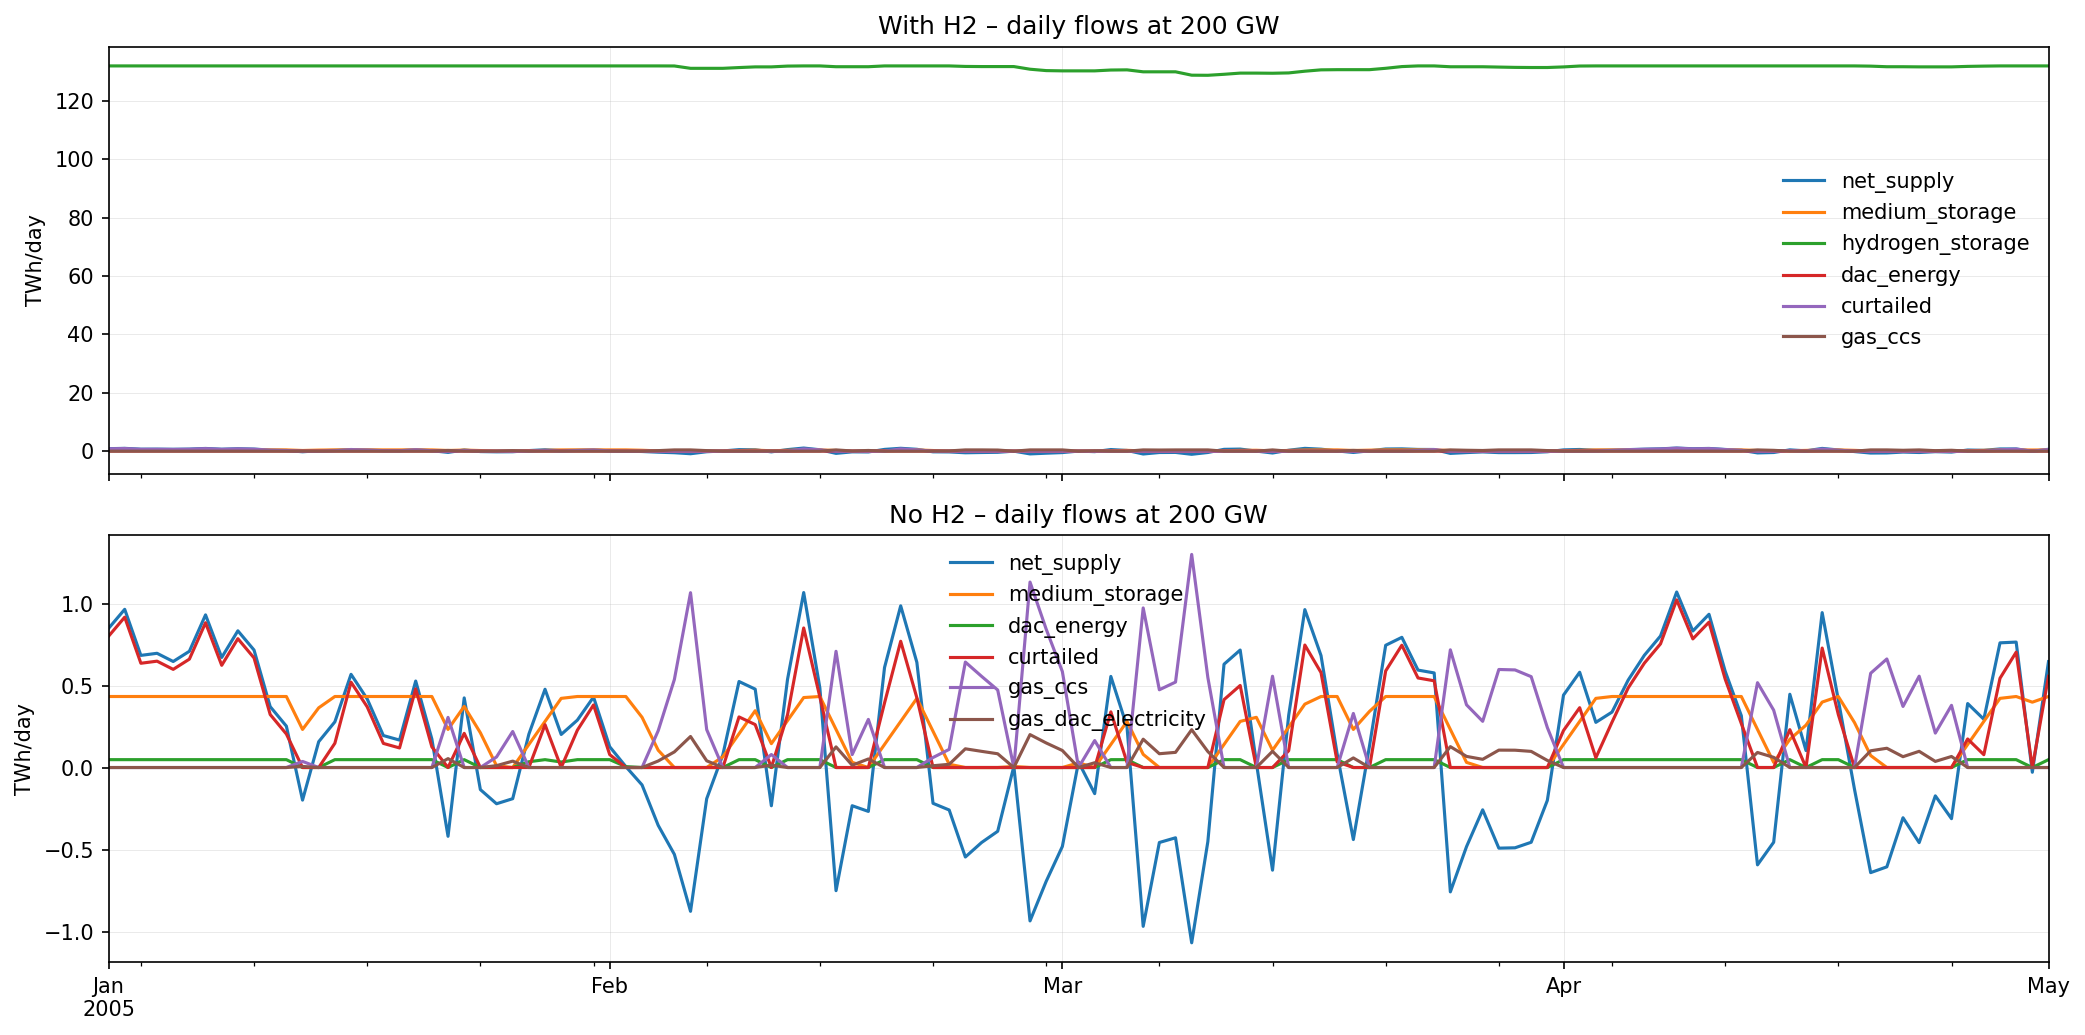

,net_supply,medium_storage,hydrogen_storage,dac_energy,curtailed,gas_ccs
2005-01-01,0.848238,0.433,132.0,0.048,0.800238,0.0
2005-01-02,0.964611,0.433,132.0,0.048,0.916611,0.0
2005-01-03,0.683690,0.433,132.0,0.048,0.635690,0.0
2005-01-04,0.696446,0.433,132.0,0.048,0.648446,0.0
2005-01-05,0.646434,0.433,132.0,0.048,0.598434,0.0
2005-01-06,0.708830,0.433,132.0,0.048,0.660830,0.0
2005-01-07,0.930612,0.433,132.0,0.048,0.882612,0.0


In [18]:
ren_gw = 200

YEAR = 2005


daily_cf = daily_cf.loc[f"{YEAR}"].copy()
demand_df = demand_df.loc[f"{YEAR}"].copy()

# Build net supply (same as your loop)
supply_df = pd.DataFrame(
    {ren_gw: daily_renewables_capacity(ren_gw * U.GW, daily_cf)},
    index=daily_cf.index,
)
common_idx = supply_df.index.intersection(demand_df.index)
supply_df = supply_df.reindex(common_idx)
demand_aligned = demand_df.reindex(common_idx)


net_supply_df = supply_df.sub(demand_aligned["demand"], axis=0)
net_supply_df = net_supply_df.rename(columns={ren_gw: f"S-D(TWh),Ren={ren_gw}GW"})
net_supply_df = net_supply_df.copy()
net_supply_df["index"] = net_supply_df.index

# Run with H2
ps_h2 = PowerSystem(
    renewable_capacity=ren_gw * U.GW,
    hydrogen_storage_capacity=HYDROGEN_STORAGE_TWH,
    electrolyser_power=ELECTROLYSER_GW,
    dac_capacity=DAC_GW * U.GW,
    hydrogen_generation_power=HYDROGEN_GEN_GW,
    enable_imports=ENABLE_IMPORTS,
    capacity_factors_source=CAPACITY_FACTORS_SOURCE,
    enable_gas_ltdac=True,

)
sim_h2 = ps_h2.run_simulation(net_supply_df)

# Run no H2
ps_no_h2 = PowerSystemNoH2(
    renewable_capacity=ren_gw * U.GW,
    dac_capacity=DAC_GW * U.GW,
    enable_imports=ENABLE_IMPORTS,
    capacity_factors_source=CAPACITY_FACTORS_SOURCE,
)
sim_no_h2 = ps_no_h2.run_simulation(net_supply_df)


def _align_index(sim_df, net_df, interconnect_df):
    if sim_df is None:
        return None, None
    if interconnect_df is not None:
        idx = net_df.index.intersection(interconnect_df.index)
    else:
        idx = net_df.index
    out = sim_df.copy()
    out.index = idx
    return out, idx


sim_h2, idx_h2 = _align_index(sim_h2, net_supply_df, ps_h2.interconnect_imports_df)
sim_no_h2, idx_no = _align_index(sim_no_h2, net_supply_df, ps_no_h2.interconnect_imports_df)

net_h2 = net_supply_df.reindex(idx_h2)[f"S-D(TWh),Ren={ren_gw}GW"]
net_no = net_supply_df.reindex(idx_no)[f"S-D(TWh),Ren={ren_gw}GW"]


# Column helpers
def _c(name, unit="TWh"):
    return f"{name} ({unit}),RC={ren_gw}GW"


# Build trace frames
trace_h2 = pd.DataFrame({
    "net_supply": net_h2,
    "medium_storage": sim_h2[_c("medium_storage_level")],
    "hydrogen_storage": sim_h2[_c("hydrogen_storage_level")],
    "dac_energy": sim_h2[_c("dac_energy")],
    "curtailed": sim_h2[_c("curtailed_energy")],
    "gas_ccs": sim_h2[_c("gas_ccs_energy")],
})

trace_no = pd.DataFrame({
    "net_supply": net_no,
    "medium_storage": sim_no_h2[_c("medium_storage_level")],
    "dac_energy": sim_no_h2[_c("dac_energy")],
    "curtailed": sim_no_h2[_c("curtailed_energy")],
    "gas_ccs": sim_no_h2[_c("gas_ccs_energy")],
    "gas_dac_capture": sim_no_h2[_c("gas_dac_capture", unit="MtCO2")],
    "gas_dac_electricity": sim_no_h2[_c("gas_dac_electricity")],
})


# Convert pint to magnitudes for plotting
def _to_mag(df):
    out = df.copy()
    for col in out.columns:
        if hasattr(out[col], "pint"):
            out[col] = out[col].pint.magnitude
    return out


trace_h2_mag = _to_mag(trace_h2)
trace_no_mag = _to_mag(trace_no)

# Plot a window for readability (adjust as needed)
start = trace_h2_mag.index[0]
end = trace_h2_mag.index[min(len(trace_h2_mag) - 1, 120)]
window_h2 = trace_h2_mag.loc[start:end]
window_no = trace_no_mag.loc[start:end]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), dpi=150, sharex=True)

window_h2[["net_supply", "medium_storage", "hydrogen_storage", "dac_energy", "curtailed", "gas_ccs"]].plot(ax=axes[0])
axes[0].set_title("With H2 – daily flows at 200 GW")
axes[0].set_ylabel("TWh/day")
axes[0].grid(True, alpha=0.3)

window_no[["net_supply", "medium_storage", "dac_energy", "curtailed", "gas_ccs", "gas_dac_electricity"]].plot(ax=axes[1])
axes[1].set_title("No H2 – daily flows at 200 GW")
axes[1].set_ylabel("TWh/day")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: show a small table of daily values
trace_h2_mag.head(7)


In [19]:
analysis_no_h2["annual_dac_energy"], A.DAC.EnergyCost.MediumTWhPerMtCO2, analysis_no_h2["annual_co2_removals"]


(<Quantity(9.55537786, 'terawatt_hour')>,
 <Quantity(0.63748138, 'terawatt_hour / megametric_ton')>,
 <Quantity(14.9892658, 'megametric_ton')>)

In [20]:
df_capture.columns, df_capture.index.names


(Index(['ren_gw', 'dac_gw', 'e_dac_with_h2', 'ltdac_with_h2', 'total_with_h2',
        'e_dac_no_h2', 'ltdac_no_h2', 'total_no_h2'],
       dtype='object'),
 FrozenList([None]))

C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_42424\3588117931.py:114: UserWarning:

The figure layout has changed to tight



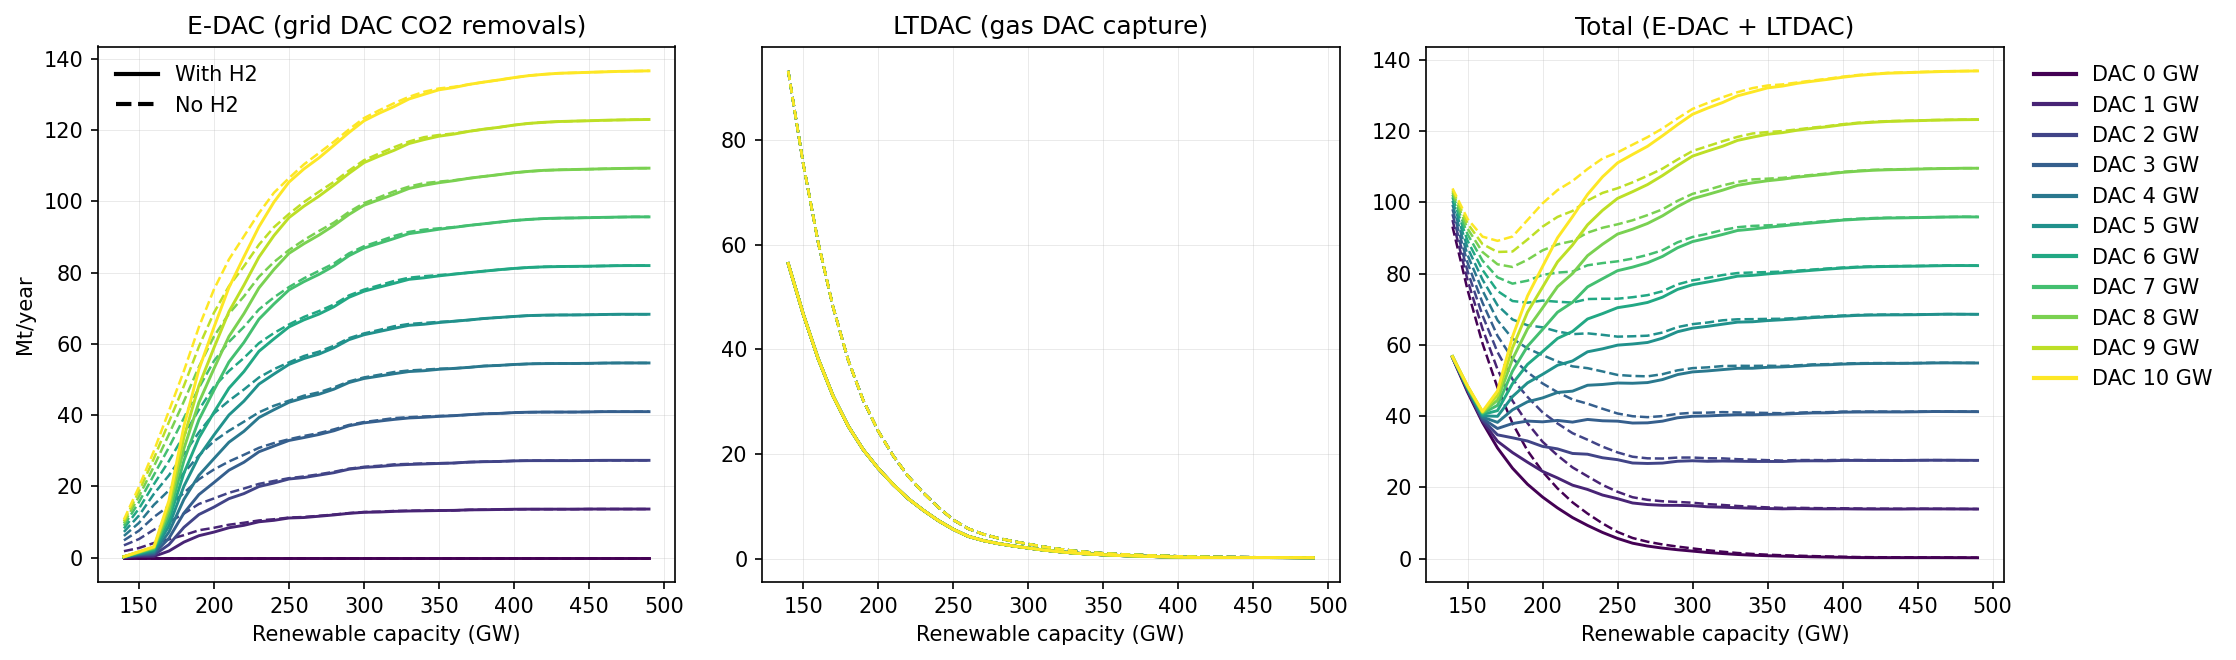

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

REN_GW_LIST = list(range(140, 500, 10))
DAC_GW_LIST = list(range(0, 11, 1))  # 0..10 GW

rows = []
for dac_gw in DAC_GW_LIST:
    for ren_gw in REN_GW_LIST:
        # build net supply
        supply_df = pd.DataFrame(
            {ren_gw: daily_renewables_capacity(ren_gw * U.GW, daily_cf)},
            index=daily_cf.index,
        )
        common_idx = supply_df.index.intersection(demand_df.index)
        supply_df = supply_df.reindex(common_idx)
        demand_aligned = demand_df.reindex(common_idx)

        net_supply_df = supply_df.sub(demand_aligned["demand"], axis=0)
        net_supply_df = net_supply_df.rename(columns={ren_gw: f"S-D(TWh),Ren={ren_gw}GW"})
        net_supply_df = net_supply_df.copy()
        net_supply_df["index"] = net_supply_df.index

        # with H2
        ps_h2 = PowerSystem(
            renewable_capacity=ren_gw * U.GW,
            hydrogen_storage_capacity=HYDROGEN_STORAGE_TWH,
            electrolyser_power=ELECTROLYSER_GW,
            dac_capacity=dac_gw * U.GW,
            hydrogen_generation_power=HYDROGEN_GEN_GW,
            enable_imports=ENABLE_IMPORTS,
            capacity_factors_source=CAPACITY_FACTORS_SOURCE,
            enable_gas_ltdac=True,

        )
        sim_h2 = ps_h2.run_simulation(net_supply_df)
        if sim_h2 is None:
            e_dac_h2 = ltdac_h2 = total_h2 = np.nan
        else:
            analysis_h2 = ps_h2.analyze_simulation_results(sim_h2)
            e_dac_h2 = analysis_h2["annual_co2_removals"].to(U.Mt).magnitude  # grid DAC
            ltdac_h2 = analysis_h2.get("annual_gas_dac_capture", 0 * U.Mt).to(U.Mt).magnitude  # gas DAC
            total_h2 = e_dac_h2 + ltdac_h2

        # no H2
        ps_no_h2 = PowerSystemNoH2(
            renewable_capacity=ren_gw * U.GW,
            dac_capacity=dac_gw * U.GW,
            enable_imports=ENABLE_IMPORTS,
            capacity_factors_source=CAPACITY_FACTORS_SOURCE,
        )
        sim_no_h2 = ps_no_h2.run_simulation(net_supply_df)
        if sim_no_h2 is None:
            e_dac_no = ltdac_no = total_no = np.nan
        else:
            analysis_no = ps_no_h2.analyze_simulation_results(sim_no_h2)
            e_dac_no = analysis_no["annual_co2_removals"].to(U.Mt).magnitude  # grid DAC
            ltdac_no = analysis_no.get("annual_gas_dac_capture", 0 * U.Mt).to(U.Mt).magnitude  # gas DAC
            total_no = e_dac_no + ltdac_no

        rows.append(
            {
                "dac_gw": dac_gw,
                "ren_gw": ren_gw,
                "e_dac_with_h2": e_dac_h2,
                "ltdac_with_h2": ltdac_h2,
                "total_with_h2": total_h2,
                "e_dac_no_h2": e_dac_no,
                "ltdac_no_h2": ltdac_no,
                "total_no_h2": total_no,
            }
        )

df_capture = pd.DataFrame(rows)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150, sharex=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(DAC_GW_LIST)))

for dac_gw, color in zip(DAC_GW_LIST, colors, strict=False):
    sub = df_capture[df_capture["dac_gw"] == dac_gw].set_index("ren_gw").sort_index()

    axes[0].plot(sub.index, sub["e_dac_with_h2"], color=color, linestyle="-", linewidth=1.4)
    axes[0].plot(sub.index, sub["e_dac_no_h2"], color=color, linestyle="--", linewidth=1.2)

    axes[1].plot(sub.index, sub["ltdac_with_h2"], color=color, linestyle="-", linewidth=1.4)
    axes[1].plot(sub.index, sub["ltdac_no_h2"], color=color, linestyle="--", linewidth=1.2)

    axes[2].plot(sub.index, sub["total_with_h2"], color=color, linestyle="-", linewidth=1.4)
    axes[2].plot(sub.index, sub["total_no_h2"], color=color, linestyle="--", linewidth=1.2)

axes[0].set_title("E-DAC (grid DAC CO2 removals)")
axes[0].set_ylabel("Mt/year")
axes[1].set_title("LTDAC (gas DAC capture)")
axes[2].set_title("Total (E-DAC + LTDAC)")

for ax in axes:
    ax.set_xlabel("Renewable capacity (GW)")
    ax.grid(True, alpha=0.3)

# Legends: color = DAC capacity, line style = H2 vs no H2
dac_handles = [Line2D([0], [0], color=c, lw=2, label=f"DAC {g} GW")
               for g, c in zip(DAC_GW_LIST, colors, strict=False)]
style_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="With H2"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="No H2"),
]

axes[0].legend(handles=style_handles, loc="upper left", frameon=False)
axes[2].legend(handles=dac_handles, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

plt.tight_layout()
plt.show()


### Why the capture converges at high Renewable Capacitiy?

Because maximum capture is limited by E-DAC capacity in both senario at high renewable energies, the E-DAC is running at its highest capacity and because the use of gas go towards 0 under high renewables, so only E-DAC is operating.

In [22]:
# ----------------------------
# 0) Imports and assumptions (same as before, but re-ordered for clarity)
# ----------------------------
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# pre-defined params：
# REN_GW, HYDROGEN_STORAGE_TWH, ELECTROLYSER_GW, HYDROGEN_GEN_GW
# DEMAND_MODE, ENABLE_IMPORTS, CAPACITY_FACTORS_SOURCE
# predicted_demand, renewable_capacity_factors, daily_renewables_capacity
# PowerSystem, PowerSystemNoH2, Units as U

# ----------------------------
# 1) compute net_supply_df
# ----------------------------
demand_df = predicted_demand(mode=DEMAND_MODE, historical="era5", filter_ldz=True)

daily_cf = renewable_capacity_factors.get_renewable_capacity_factors(
    source=CAPACITY_FACTORS_SOURCE,
    resample="D",
)

common_idx = daily_cf.index.intersection(demand_df.index)
daily_cf = daily_cf.reindex(common_idx)
demand_df = demand_df.reindex(common_idx)

supply_df = pd.DataFrame(
    {REN_GW: daily_renewables_capacity(REN_GW * U.GW, daily_cf)},
    index=daily_cf.index,
)

net_supply_df = supply_df.sub(demand_df["demand"], axis=0)
net_supply_df = net_supply_df.rename(columns={REN_GW: f"S-D(TWh),Ren={REN_GW}GW"})

# keep datetime index，adding "index" for PowerSystem aline imports
net_supply_df["index"] = net_supply_df.index

print("days:", len(net_supply_df))

# ----------------------------
# 2) calculate Grid-DAC Capacity（Same net_supply_df）
# ----------------------------
TARGET_NET_CAPTURE_MT = 35.8
DAC_MAX_GW = 50
TOL_MT = 0.1


def _net_capture_mt(dac_gw: float, mode: str) -> float | None:
    if mode == "with_h2":
        ps = PowerSystem(
            renewable_capacity=REN_GW * U.GW,
            hydrogen_storage_capacity=HYDROGEN_STORAGE_TWH,
            electrolyser_power=ELECTROLYSER_GW,
            dac_capacity=dac_gw * U.GW,
            hydrogen_generation_power=HYDROGEN_GEN_GW,
            enable_imports=ENABLE_IMPORTS,
            capacity_factors_source=CAPACITY_FACTORS_SOURCE,
            enable_gas_ltdac=True,

        )
    elif mode == "no_h2":
        ps = PowerSystemNoH2(
            renewable_capacity=REN_GW * U.GW,
            dac_capacity=dac_gw * U.GW,
            enable_imports=ENABLE_IMPORTS,
            capacity_factors_source=CAPACITY_FACTORS_SOURCE,
        )
    else:
        raise ValueError(f"Unknown mode: {mode}")

    sim = ps.run_simulation(net_supply_df)
    if sim is None:
        return None
    analysis = ps.analyze_simulation_results(sim)
    return analysis["annual_net_capture"].to(U.Mt).magnitude


def _find_dac_gw(
    target_mt: float,
    mode: str,
    dac_min: float = 0.0,
    dac_max: float = DAC_MAX_GW,
    tol_mt: float = TOL_MT,
    max_iter: int = 30,
) -> dict:
    low = dac_min
    high = dac_max
    low_val = _net_capture_mt(low, mode)
    high_val = _net_capture_mt(high, mode)

    if low_val is None or high_val is None:
        return {"mode": mode, "dac_gw": np.nan, "net_capture_mt": np.nan, "status": "simulation_failed"}

    while high_val < target_mt and high < 400:
        low, low_val = high, high_val
        high *= 2
        high_val = _net_capture_mt(high, mode)
        if high_val is None:
            return {"mode": mode, "dac_gw": np.nan, "net_capture_mt": np.nan, "status": "simulation_failed"}

    if high_val < target_mt:
        return {
            "mode": mode,
            "dac_gw": np.nan,
            "net_capture_mt": high_val,
            "status": "target_unreachable_with_surplus",
        }

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        mid_val = _net_capture_mt(mid, mode)
        if mid_val is None:
            return {"mode": mode, "dac_gw": np.nan, "net_capture_mt": np.nan, "status": "simulation_failed"}

        if abs(mid_val - target_mt) <= tol_mt:
            return {"mode": mode, "dac_gw": mid, "net_capture_mt": mid_val, "status": "ok"}

        if mid_val < target_mt:
            low, low_val = mid, mid_val
        else:
            high, high_val = mid, mid_val

    return {"mode": mode, "dac_gw": mid, "net_capture_mt": mid_val, "status": "max_iter"}


results = [_find_dac_gw(TARGET_NET_CAPTURE_MT, mode) for mode in ["with_h2", "no_h2"]]
results_df = pd.DataFrame(results)
results_df["target_net_capture_mt"] = TARGET_NET_CAPTURE_MT
results_df


days: 14967


,mode,dac_gw,net_capture_mt,status,target_net_capture_mt
0,with_h2,5.419922,35.789568,ok,35.8
1,no_h2,2.612305,35.869063,ok,35.8


with_h2 net capture (Mt): 35.78956844599121 megametric_ton
no_h2  net capture (Mt): 35.869063465443624 megametric_ton


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_42424\4058219116.py:97: UserWarning:

This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.



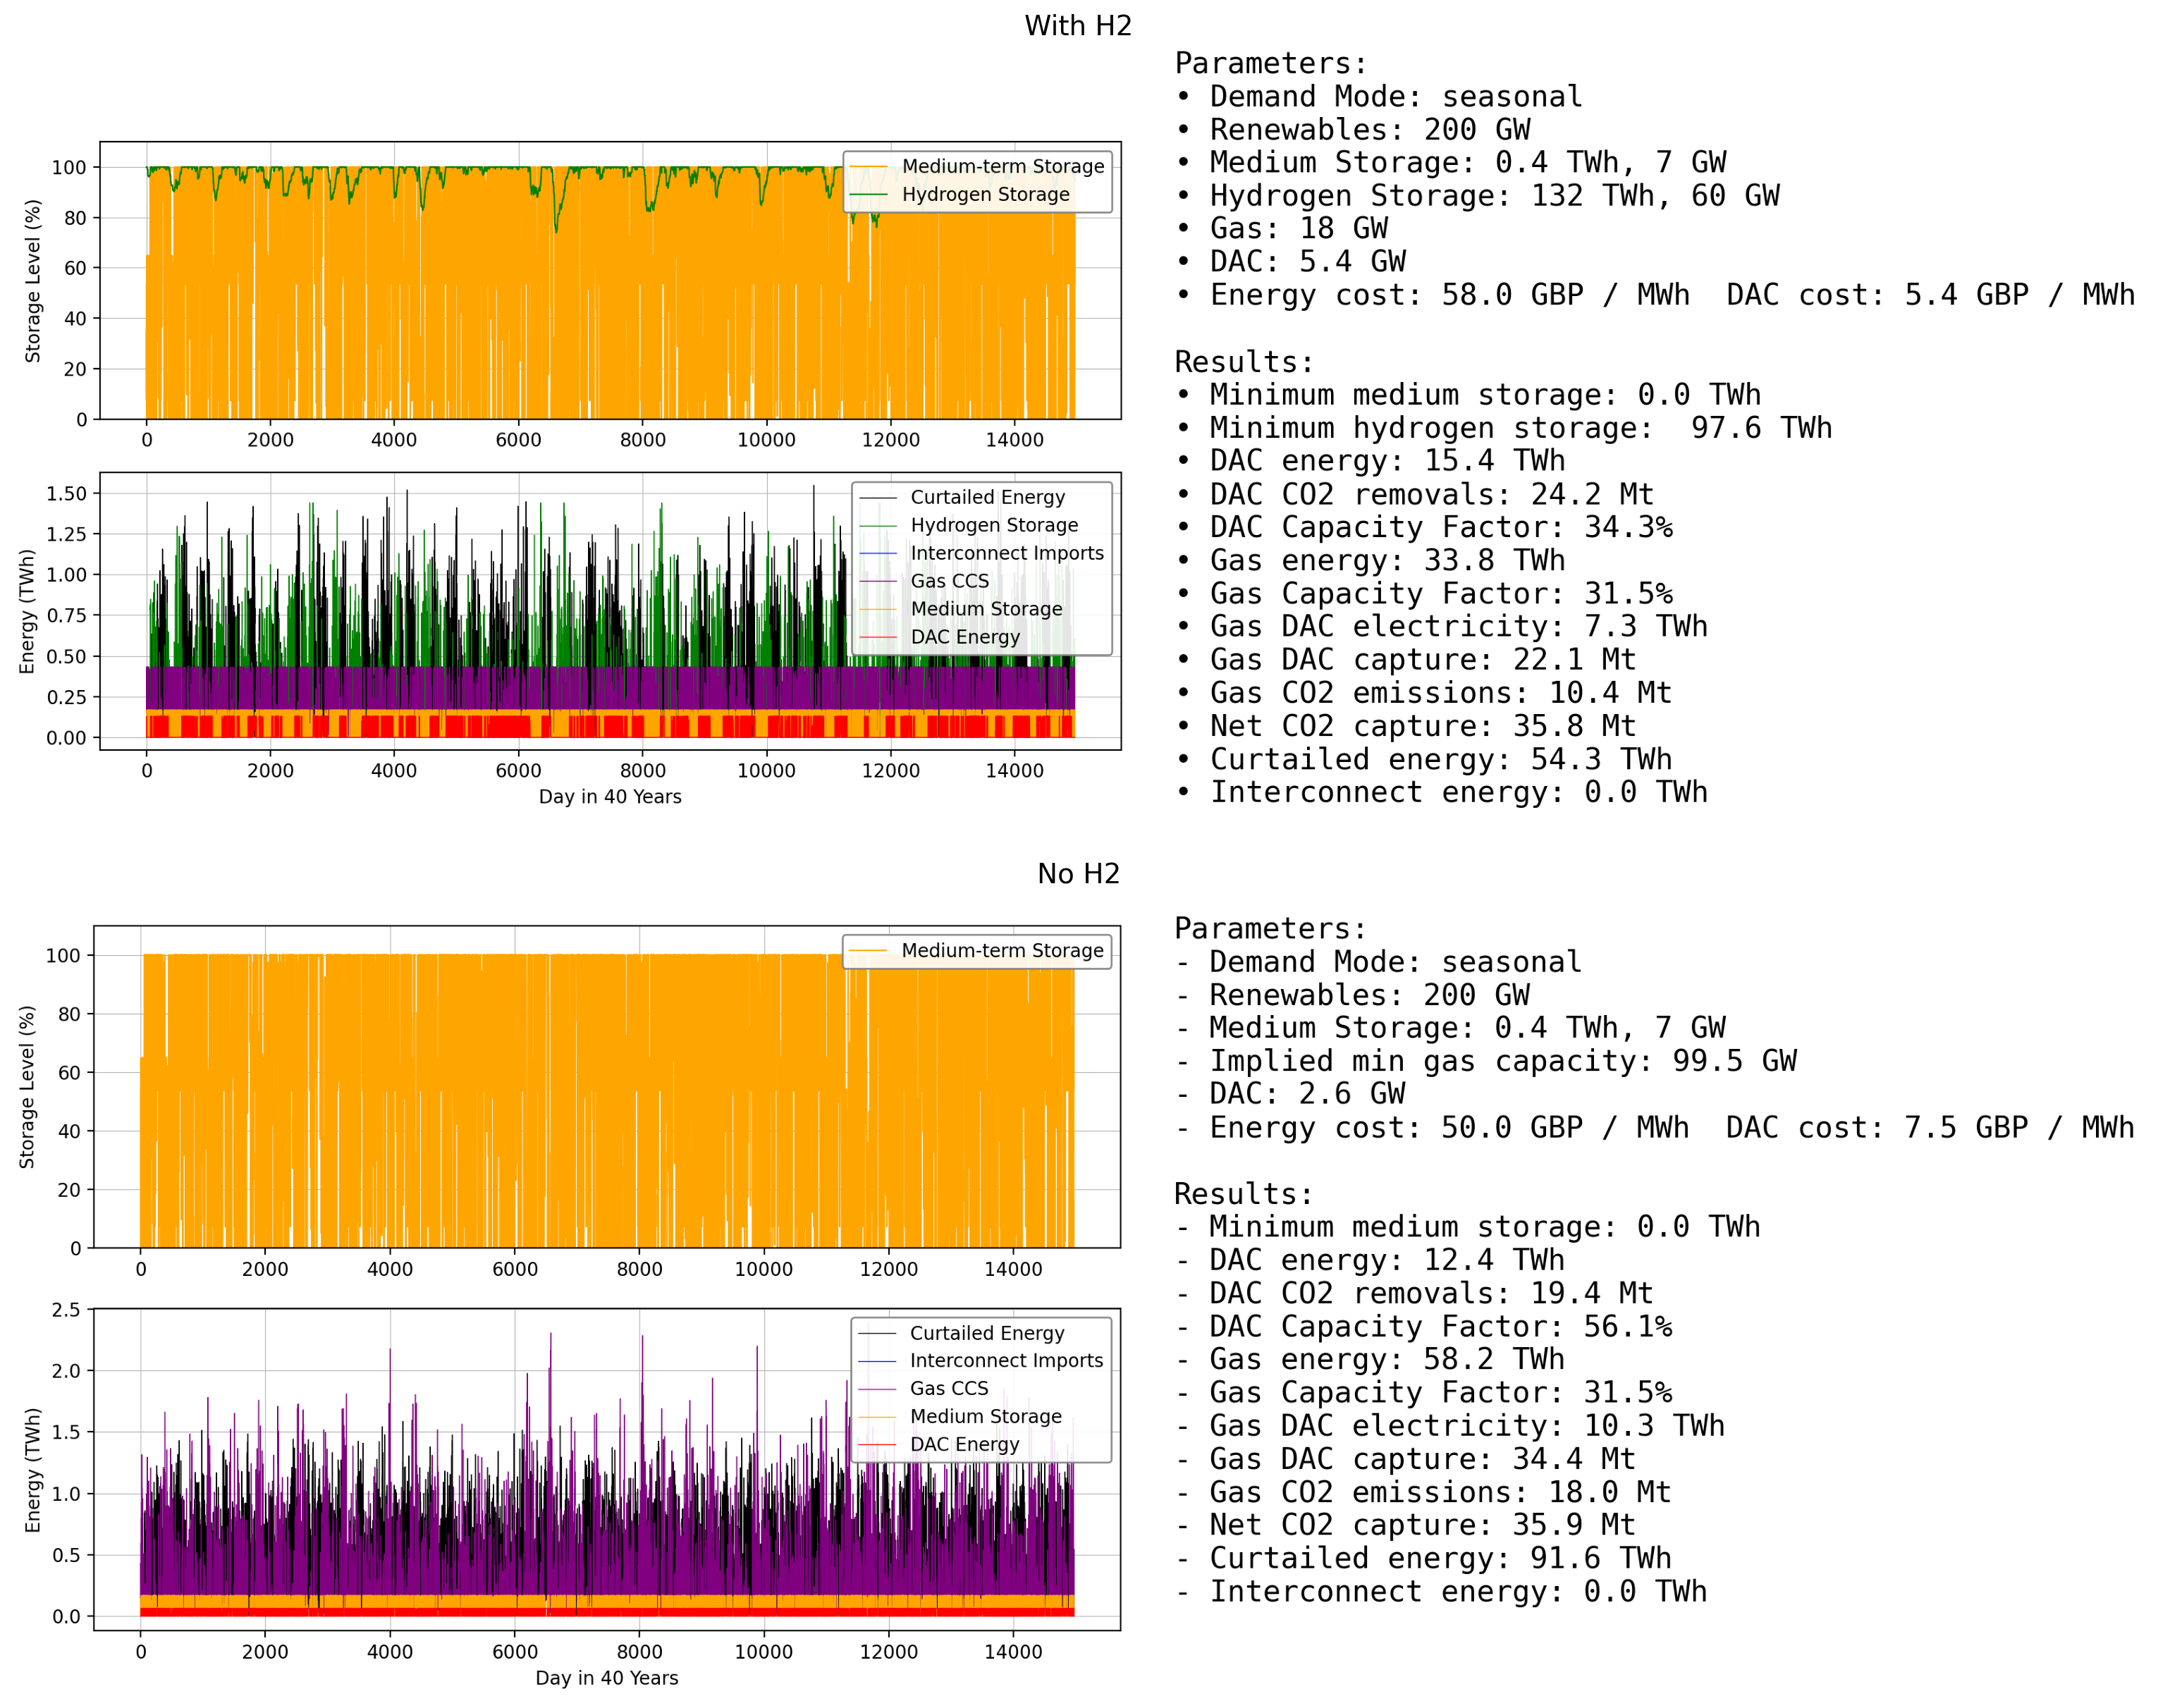

In [23]:
# ----------------------------
# 3) Use calculated DAC to run simulation and plot results
# ----------------------------
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps

DAC_GW_H2 = float(results_df.loc[results_df["mode"] == "with_h2", "dac_gw"].iloc[0])
DAC_GW_NO_H2 = float(results_df.loc[results_df["mode"] == "no_h2", "dac_gw"].iloc[0])

ps_h2 = PowerSystem(
    renewable_capacity=REN_GW * U.GW,
    hydrogen_storage_capacity=HYDROGEN_STORAGE_TWH,
    electrolyser_power=ELECTROLYSER_GW,
    dac_capacity=DAC_GW_H2 * U.GW,
    hydrogen_generation_power=HYDROGEN_GEN_GW,
    enable_imports=ENABLE_IMPORTS,
    capacity_factors_source=CAPACITY_FACTORS_SOURCE,
    enable_gas_ltdac=True,
)
ps_no_h2 = PowerSystemNoH2(
    renewable_capacity=REN_GW * U.GW,
    dac_capacity=DAC_GW_NO_H2 * U.GW,
    enable_imports=ENABLE_IMPORTS,
    capacity_factors_source=CAPACITY_FACTORS_SOURCE,
)

sim_h2 = ps_h2.run_simulation(net_supply_df)
sim_no_h2 = ps_no_h2.run_simulation(net_supply_df)

if sim_h2 is None or sim_no_h2 is None:
    failed = []
    if sim_h2 is None:
        failed.append("with_h2")
    if sim_no_h2 is None:
        failed.append("no_h2")
    raise SystemExit(f"Simulation failed for: {', '.join(failed)}")

analysis_h2 = ps_h2.analyze_simulation_results(sim_h2)
analysis_no_h2 = ps_no_h2.analyze_simulation_results(sim_no_h2)

print("with_h2 net capture (Mt):", analysis_h2["annual_net_capture"].to(U.Mt))
print("no_h2  net capture (Mt):", analysis_no_h2["annual_net_capture"].to(U.Mt))

# Save two plots with fixed canvas settings (no tight bbox)
OUTPUT_DIR = Path("nbs/output/h2_vs_no_h2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plot_h2_path = OUTPUT_DIR / "plot_with_h2.png"
plot_no_h2_path = OUTPUT_DIR / "plot_no_h2.png"

ps_h2.plot_simulation_results(sim_h2, analysis_h2, DEMAND_MODE)
fig_h2 = plt.gcf()
fig_h2.set_layout_engine(None)
fig_h2.set_size_inches(16, 6, forward=True)
fig_h2.savefig(plot_h2_path, dpi=200, bbox_inches=None)
plt.close(fig_h2)

ps_no_h2.plot_simulation_results(sim_no_h2, analysis_no_h2, DEMAND_MODE)
fig_no = plt.gcf()
fig_no.set_layout_engine(None)
fig_no.set_size_inches(16, 6, forward=True)
fig_no.savefig(plot_no_h2_path, dpi=200, bbox_inches=None)
plt.close(fig_no)

# Normalize both images to identical final pixel canvas for perfect vertical alignment
img_h2 = Image.open(plot_h2_path).convert("RGBA")
img_no = Image.open(plot_no_h2_path).convert("RGBA")

target_w = max(img_h2.width, img_no.width)
target_h = max(img_h2.height, img_no.height)


def to_common_canvas(im, size, bg=(255, 255, 255, 255)):
    fitted = ImageOps.contain(im, size, method=Image.Resampling.LANCZOS)
    canvas = Image.new("RGBA", size, bg)
    x = (size[0] - fitted.width) // 2
    y = (size[1] - fitted.height) // 2
    canvas.paste(fitted, (x, y))
    return np.asarray(canvas)


arr_h2 = to_common_canvas(img_h2, (target_w, target_h))
arr_no = to_common_canvas(img_no, (target_w, target_h))

# Display stacked without tight/constrained layout engine
fig, axes = plt.subplots(2, 1, figsize=(16, 12), dpi=200)
fig.set_layout_engine(None)

axes[0].imshow(arr_h2)
axes[0].set_title("With H2", fontsize=14)
axes[0].axis("off")

axes[1].imshow(arr_no)
axes[1].set_title("No H2", fontsize=14)
axes[1].axis("off")

fig.subplots_adjust(hspace=0.08, top=0.96, bottom=0.04, left=0.03, right=0.97)
plt.show()


In [24]:
import pandas as pd

import src.assumptions as A
from src.costs import total_system_cost
from src.power_system import PowerSystem
from src.power_system_no_h2 import PowerSystemNoH2
from src.units import Units as U


def split_cost(ps, sim_df):
    if isinstance(ps, PowerSystem):
        base = total_system_cost(
            energy_demand=A.EnergyDemand2050,
            renewable_capacity=ps.renewable_capacity * U.GW,
            renewable_capacity_factor=A.Renewables.AverageCapacityFactor,
            renewable_lcoe=A.Renewables.AverageLCOE,
            nuclear_capacity=A.Nuclear.Capacity,
            nuclear_capacity_factor=A.Nuclear.CapacityFactor,
            nuclear_lcoe=A.Nuclear.AverageLCOE,
            storage_capacity=ps.hydrogen_storage_capacity * U.TWh,
            electrolyser_power=ps.electrolyser_power * U.GW,
            generation_capacity=ps.hydrogen_generation_power * U.GW,
        )
    elif isinstance(ps, PowerSystemNoH2):
        base = total_system_cost(
            energy_demand=A.EnergyDemand2050,
            renewable_capacity=ps.renewable_capacity * U.GW,
            renewable_capacity_factor=A.Renewables.AverageCapacityFactor,
            renewable_lcoe=A.Renewables.AverageLCOE,
            nuclear_capacity=A.Nuclear.Capacity,
            nuclear_capacity_factor=A.Nuclear.CapacityFactor,
            nuclear_lcoe=A.Nuclear.AverageLCOE,
            storage_capacity=ps.medium_storage_capacity * U.TWh,
            electrolyser_power=0 * U.GW,
            generation_capacity=0 * U.GW,
        )
    else:
        raise TypeError(f"Unsupported power system type: {type(ps)}")

    total = ps.calculate_power_system_cost(sim_df)
    additional = total - base
    return base, additional, total


rows = []
for label, (ps, sim_df) in {
    "with_h2": (ps_h2, sim_h2),
    "no_h2": (ps_no_h2, sim_no_h2),
}.items():
    base, additional, total = split_cost(ps, sim_df)
    rows.append({
        "mode": label,
        "base_cost_gbp": f"{base:~0.2f}",
        "additional_cost_gbp": f"{additional:~0.2f}",
        "total_cost_gbp": f"{total:~0.2f}",
        "base_cost_gbp_per_mwh": f"{(base / A.EnergyDemand2050).to(U.GBP / U.MWh):~0.2f}",
        "additional_cost_gbp_per_mwh": f"{(additional / A.EnergyDemand2050).to(U.GBP / U.MWh):~0.2f}",
        "total_cost_gbp_per_mwh": f"{(total / A.EnergyDemand2050).to(U.GBP / U.MWh):~0.2f}",
    })

pd.DataFrame(rows)


,mode,base_cost_gbp,additional_cost_gbp,total_cost_gbp,base_cost_gbp_per_mwh,additional_cost_gbp_per_mwh,total_cost_gbp_per_mwh
0,with_h2,34810511734.89 GBP,5344456911.22 GBP,40154968646.11 GBP,50.30 GBP / MWh,7.72 GBP / MWh,58.03 GBP / MWh
1,no_h2,26476494398.56 GBP,8122888630.72 GBP,34599383029.27 GBP,38.26 GBP / MWh,11.74 GBP / MWh,50.00 GBP / MWh


In [25]:
import pandas as pd

import src.assumptions as A
from src.costs import total_storage_cost, yearly_cost
from src.power_system import PowerSystem
from src.power_system_no_h2 import PowerSystemNoH2
from src.units import Units as U


def base_cost_breakdown(ps):
    if isinstance(ps, PowerSystem):
        storage_capacity = ps.hydrogen_storage_capacity * U.TWh
        electrolyser_power = ps.electrolyser_power * U.GW
        generation_capacity = ps.hydrogen_generation_power * U.GW
        renewable_capacity = ps.renewable_capacity * U.GW
    elif isinstance(ps, PowerSystemNoH2):
        storage_capacity = ps.medium_storage_capacity * U.TWh
        electrolyser_power = 0 * U.GW
        generation_capacity = 0 * U.GW
        renewable_capacity = ps.renewable_capacity * U.GW
    else:
        raise TypeError(f"Unsupported power system type: {type(ps)}")

    renewable = yearly_cost(
        capacity=renewable_capacity,
        capacity_factor=A.Renewables.AverageCapacityFactor,
        lcoe=A.Renewables.AverageLCOE,
    )
    nuclear = yearly_cost(
        capacity=A.Nuclear.Capacity,
        capacity_factor=A.Nuclear.CapacityFactor,
        lcoe=A.Nuclear.AverageLCOE,
    )
    storage = total_storage_cost(
        storage_capacity=storage_capacity,
        electrolyser_power=electrolyser_power,
        generation_capacity=generation_capacity,
    )
    additional_system = A.AdditionalCosts * A.EnergyDemand2050
    base_total = (renewable + nuclear + storage + additional_system).to(U.GBP)
    residual = base_total - (renewable + nuclear + storage + additional_system)

    return {
        "renewable_gbp": renewable,
        "nuclear_gbp": nuclear,
        "storage_gbp": storage,
        "additional_system_gbp": additional_system,
        "base_total_gbp": base_total,
        "residual_gbp": residual,
    }


rows = []
for label, ps in {"with_h2": ps_h2, "no_h2": ps_no_h2}.items():
    b = base_cost_breakdown(ps)
    rows.append({
        "mode": label,
        "renewable_gbp": f"{b['renewable_gbp']:~0.2f}",
        "nuclear_gbp": f"{b['nuclear_gbp']:~0.2f}",
        "storage_gbp": f"{b['storage_gbp']:~0.2f}",
        "additional_system_gbp": f"{b['additional_system_gbp']:~0.2f}",
        "base_total_gbp": f"{b['base_total_gbp']:~0.2f}",
        "leftover_gbp": f"{b['residual_gbp']:~0.2f}",
    })

pd.DataFrame(rows)


,mode,renewable_gbp,nuclear_gbp,storage_gbp,additional_system_gbp,base_total_gbp,leftover_gbp
0,with_h2,16310151090.00 GBP,7384478400.00 GBP,8347882244.89 GBP,2768000000.00 GBP,34810511734.89 GBP,0.00 GBP
1,no_h2,16310151090.00 GBP,7384478400.00 GBP,13864908.56 GBP,2768000000.00 GBP,26476494398.56 GBP,0.00 GBP


In [26]:
import pandas as pd

import src.assumptions as A
from src.power_system import PowerSystem
from src.power_system_no_h2 import PowerSystemNoH2
from src.units import Units as U


def _fmt(x):
    return f"{x:~0.2f}" if hasattr(x, "units") else x


def base_cost_formula_breakdown(ps):
    # Renewable
    ren_cap = ps.renewable_capacity * U.GW
    ren_cf = A.Renewables.AverageCapacityFactor
    ren_hours = A.HoursPerYear
    ren_lcoe = A.Renewables.AverageLCOE
    ren_energy = ren_cap * ren_cf * ren_hours
    ren_cost = (ren_energy * ren_lcoe).to(U.GBP)

    # Nuclear
    nuc_cap = A.Nuclear.Capacity
    nuc_cf = A.Nuclear.CapacityFactor
    nuc_hours = A.HoursPerYear
    nuc_lcoe = A.Nuclear.AverageLCOE
    nuc_energy = nuc_cap * nuc_cf * nuc_hours
    nuc_cost = (nuc_energy * nuc_lcoe).to(U.GBP)

    # Storage (same formula as total_storage_cost)
    if isinstance(ps, PowerSystem):
        storage_capacity = ps.hydrogen_storage_capacity * U.TWh
        electrolyser_power = ps.electrolyser_power * U.GW
        generation_power = ps.hydrogen_generation_power * U.GW
    elif isinstance(ps, PowerSystemNoH2):
        storage_capacity = ps.medium_storage_capacity * U.TWh
        electrolyser_power = 0 * U.GW
        generation_power = 0 * U.GW
    else:
        raise TypeError(f"Unsupported power system type: {type(ps)}")

    storage_capacity_cost = (storage_capacity * A.HydrogenStorage.CavernStorage.AnnualisedCost).to(U.GBP)
    electrolyser_cost = (electrolyser_power * A.HydrogenStorage.Electrolysis.AnnualisedCost).to(U.GBP)
    generation_cost = (generation_power * A.HydrogenStorage.Generation.AnnualisedCost).to(U.GBP)
    storage_total = (storage_capacity_cost + electrolyser_cost + generation_cost).to(U.GBP)

    # Additional system
    additional_rate = A.AdditionalCosts
    energy_demand = A.EnergyDemand2050
    additional_cost = (additional_rate * energy_demand).to(U.GBP)

    base_total = (ren_cost + nuc_cost + storage_total + additional_cost).to(U.GBP)

    return {
        # Renewable formula parts
        "ren_capacity": ren_cap,
        "ren_capacity_factor": ren_cf,
        "ren_hours_per_year": ren_hours,
        "ren_lcoe": ren_lcoe,
        "ren_energy": ren_energy,
        "ren_cost": ren_cost,

        # Nuclear formula parts
        "nuc_capacity": nuc_cap,
        "nuc_capacity_factor": nuc_cf,
        "nuc_hours_per_year": nuc_hours,
        "nuc_lcoe": nuc_lcoe,
        "nuc_energy": nuc_energy,
        "nuc_cost": nuc_cost,

        # Storage formula parts
        "storage_capacity": storage_capacity,
        "storage_capacity_cost": storage_capacity_cost,
        "electrolyser_power": electrolyser_power,
        "electrolyser_cost": electrolyser_cost,
        "generation_power": generation_power,
        "generation_cost": generation_cost,
        "storage_total": storage_total,

        # Additional system
        "additional_cost_rate": additional_rate,
        "energy_demand": energy_demand,
        "additional_cost": additional_cost,

        # Base total
        "base_total": base_total,
    }


rows = []
for label, ps in {"with_h2": ps_h2, "no_h2": ps_no_h2}.items():
    b = base_cost_formula_breakdown(ps)
    row = {"mode": label}
    row.update({k: _fmt(v) for k, v in b.items()})
    rows.append(row)

pd.DataFrame(rows)


,mode,ren_capacity,ren_capacity_factor,ren_hours_per_year,ren_lcoe,ren_energy,ren_cost,nuc_capacity,nuc_capacity_factor,nuc_hours_per_year,...,storage_capacity_cost,electrolyser_power,electrolyser_cost,generation_power,generation_cost,storage_total,additional_cost_rate,energy_demand,additional_cost,base_total
0,with_h2,200.00 GW,0.2595,8766.00 h,35.85 GBP / MWh,454955.40 GW * h,16310151090.00 GBP,12.00 GW,0.9,8766.00 h,...,4226715772.24 GBP,60.00 GW,1601028701.61 GBP,100.00 GW,2520137771.05 GBP,8347882244.89 GBP,4.00 GBP / MWh,692.00 TWh,2768000000.00 GBP,34810511734.89 GBP
1,no_h2,200.00 GW,0.2595,8766.00 h,35.85 GBP / MWh,454955.40 GW * h,16310151090.00 GBP,12.00 GW,0.9,8766.00 h,...,13864908.56 GBP,0.00 GW,0.00 GBP,0.00 GW,0.00 GBP,13864908.56 GBP,4.00 GBP / MWh,692.00 TWh,2768000000.00 GBP,26476494398.56 GBP


In [27]:
import pandas as pd

import src.assumptions as A
from src.power_system import PowerSystem
from src.power_system_no_h2 import PowerSystemNoH2
from src.units import Units as U


def additional_cost_breakdown(ps, sim_df):
    rc = int(ps.renewable_capacity)
    gas_ccs_col = f"gas_ccs_energy (TWh),RC={rc}GW"
    gas_dac_elec_col = f"gas_dac_electricity (TWh),RC={rc}GW"
    medium_storage_col = f"energy_into_medium_storage (TWh),RC={rc}GW"
    dac_col = f"dac_energy (TWh),RC={rc}GW"
    gas_dac_capture_col = f"gas_dac_capture (MtCO2),RC={rc}GW"

    annual_gas_ccs_energy = sim_df[gas_ccs_col].mean() * 365
    annual_gas_dac_electricity = sim_df[gas_dac_elec_col].mean() * 365
    net_gas_ccs_energy = annual_gas_ccs_energy - annual_gas_dac_electricity
    gas_ccs_cost = net_gas_ccs_energy * A.DispatchableGasCCS.LCOE

    annual_medium_storage_energy = sim_df[medium_storage_col].mean() * 365
    medium_storage_cost = annual_medium_storage_energy * A.MediumTermStorage.LCOE

    annual_dac_energy = sim_df[dac_col].mean() * 365
    edac_cost = annual_dac_energy * A.EDAC.LCOE

    annual_gas_dac_capture = sim_df[gas_dac_capture_col].mean() * 365
    gas_dac_electricity_emissions = (
        annual_gas_dac_electricity.to(U.MWh) * A.GasTechDACParameters.GasCO2Intensity
    ).to(U.t)
    net_gas_dac_capture = annual_gas_dac_capture.to(U.t) - gas_dac_electricity_emissions
    gas_dac_cost = net_gas_dac_capture * A.LTDAC.LCOR

    additional_total = gas_ccs_cost + medium_storage_cost + edac_cost + gas_dac_cost

    return {
        "gas_ccs_cost_gbp": gas_ccs_cost,
        "medium_storage_cost_gbp": medium_storage_cost,
        "edac_cost_gbp": edac_cost,
        "gas_dac_cost_gbp": gas_dac_cost,
        "additional_total_gbp": additional_total,
    }


rows = []
for label, (ps, sim_df) in {
    "with_h2": (ps_h2, sim_h2),
    "no_h2": (ps_no_h2, sim_no_h2),
}.items():
    b = additional_cost_breakdown(ps, sim_df)
    rows.append({
        "mode": label,
        **{k: f"{v:~0.2f}" for k, v in b.items()},
    })

pd.DataFrame(rows)


,mode,gas_ccs_cost_gbp,medium_storage_cost_gbp,edac_cost_gbp,gas_dac_cost_gbp,additional_total_gbp
0,with_h2,3025975475.01 GBP,1485787073.75 GBP,875800354.89 GBP,2598102962.90 GBP,7985665866.55 GBP
1,no_h2,5459048262.86 GBP,1485787073.75 GBP,703862967.95 GBP,4094501691.78 GBP,11743199996.34 GBP


In [28]:
import pandas as pd

import src.assumptions as A
from src.units import Units as U


def gas_ccs_cost_breakdown(ps, sim_df, label):
    rc = int(ps.renewable_capacity)
    gas_ccs_col = f"gas_ccs_energy (TWh),RC={rc}GW"
    gas_dac_elec_col = f"gas_dac_electricity (TWh),RC={rc}GW"

    annual_gas_ccs_energy = sim_df[gas_ccs_col].mean() * 365
    annual_gas_dac_electricity = sim_df[gas_dac_elec_col].mean() * 365
    net_gas_ccs_energy = annual_gas_ccs_energy - annual_gas_dac_electricity
    lcoe = A.DispatchableGasCCS.LCOE
    gas_ccs_cost = net_gas_ccs_energy * lcoe

    return {
        "mode": label,
        "annual_gas_ccs_energy": f"{annual_gas_ccs_energy:~0.2f}",
        "annual_gas_dac_electricity": f"{annual_gas_dac_electricity:~0.2f}",
        "net_gas_ccs_energy": f"{net_gas_ccs_energy:~0.2f}",
        "gas_ccs_lcoe": f"{lcoe:~0.2f}",
        "gas_ccs_cost_gbp": f"{gas_ccs_cost:~0.2f}",
    }


rows = []
rows.append(gas_ccs_cost_breakdown(ps_h2, sim_h2, "with_h2"))
rows.append(gas_ccs_cost_breakdown(ps_no_h2, sim_no_h2, "no_h2"))

pd.DataFrame(rows)


,mode,annual_gas_ccs_energy,annual_gas_dac_electricity,net_gas_ccs_energy,gas_ccs_lcoe,gas_ccs_cost_gbp
0,with_h2,33.85 TWh,7.30 TWh,26.54 TWh,114.00 GBP / MWh,3025975475.01 GBP
1,no_h2,58.22 TWh,10.33 TWh,47.89 TWh,114.00 GBP / MWh,5459048262.86 GBP


In [29]:
import src.assumptions as A
from src.units import Units as U

print("ps_h2 storage_capacity:", ps_h2.hydrogen_storage_capacity * U.TWh)
print("ps_no_h2 storage_capacity:", ps_no_h2.medium_storage_capacity * U.TWh)
print("CavernStorage AnnualisedCost:", A.HydrogenStorage.CavernStorage.AnnualisedCost)


ps_h2 storage_capacity: 132.0 terawatt_hour
ps_no_h2 storage_capacity: 0.433 terawatt_hour
CavernStorage AnnualisedCost: 32.02057403211062 GBP / megawatt_hour


In [30]:
import src.assumptions as A
from src.units import Units as U

rc = int(ps_no_h2.renewable_capacity)
col = f"energy_into_medium_storage (TWh),RC={rc}GW"

annual_medium_storage_energy = sim_no_h2[col].mean() * 365
medium_storage_cost_gbp = (annual_medium_storage_energy * A.MediumTermStorage.LCOE).to(U.GBP)

print("annual_medium_storage_energy:", annual_medium_storage_energy)
print("medium_storage_cost_gbp:", medium_storage_cost_gbp)


annual_medium_storage_energy: 14.857870737494803 terawatt_hour
medium_storage_cost_gbp: 1485787073.7494802 GBP


In [31]:
import src.assumptions as A
from src.units import Units as U

rc = int(ps_no_h2.renewable_capacity)
col = f"dac_energy (TWh),RC={rc}GW"

annual_dac_energy = sim_no_h2[col].mean() * 365
edac_cost_gbp = (annual_dac_energy * A.EDAC.LCOE).to(U.GBP)

print("annual_dac_energy:", annual_dac_energy)
print("edac_cost_gbp:", edac_cost_gbp)


annual_dac_energy: 12.383233074370777 terawatt_hour
edac_cost_gbp: 703862967.947235 GBP


In [32]:
import pandas as pd

import src.assumptions as A
from src.units import Units as U


def gas_dac_cost_table(ps, sim_df, label):
    rc = int(ps.renewable_capacity)
    cap_col = f"gas_dac_capture (MtCO2),RC={rc}GW"
    elec_col = f"gas_dac_electricity (TWh),RC={rc}GW"

    annual_gas_dac_capture = sim_df[cap_col].mean() * 365
    annual_gas_dac_electricity = sim_df[elec_col].mean() * 365

    gas_dac_electricity_emissions = (
        annual_gas_dac_electricity.to(U.MWh) * A.GasTechDACParameters.GasCO2Intensity
    ).to(U.t)

    net_gas_dac_capture = annual_gas_dac_capture.to(U.t) - gas_dac_electricity_emissions
    gas_dac_cost_gbp = (net_gas_dac_capture * A.LTDAC.LCOR).to(U.GBP)

    return {
        "mode": label,
        "annual_gas_dac_capture": f"{annual_gas_dac_capture:~0.2f}",
        "annual_gas_dac_electricity": f"{annual_gas_dac_electricity:~0.2f}",
        "gas_dac_electricity_emissions": f"{gas_dac_electricity_emissions:~0.2f}",
        "net_gas_dac_capture": f"{net_gas_dac_capture:~0.2f}",
        "LTDAC_LCOR": f"{A.LTDAC.LCOR:~0.2f}",
        "gas_dac_cost_gbp": f"{gas_dac_cost_gbp:~0.2f}",
    }


rows = [
    gas_dac_cost_table(ps_h2, sim_h2, "with_h2"),
    gas_dac_cost_table(ps_no_h2, sim_no_h2, "no_h2"),
]

pd.DataFrame(rows)


,mode,annual_gas_dac_capture,annual_gas_dac_electricity,gas_dac_electricity_emissions,net_gas_dac_capture,LTDAC_LCOR,gas_dac_cost_gbp
0,with_h2,22.06 Mt,7.30 TWh,2483474.41 ton,21832798.01 ton,119.00 GBP / ton,2598102962.90 GBP
1,no_h2,34.40 Mt,10.33 TWh,3513492.28 ton,34407577.24 ton,119.00 GBP / ton,4094501691.78 GBP


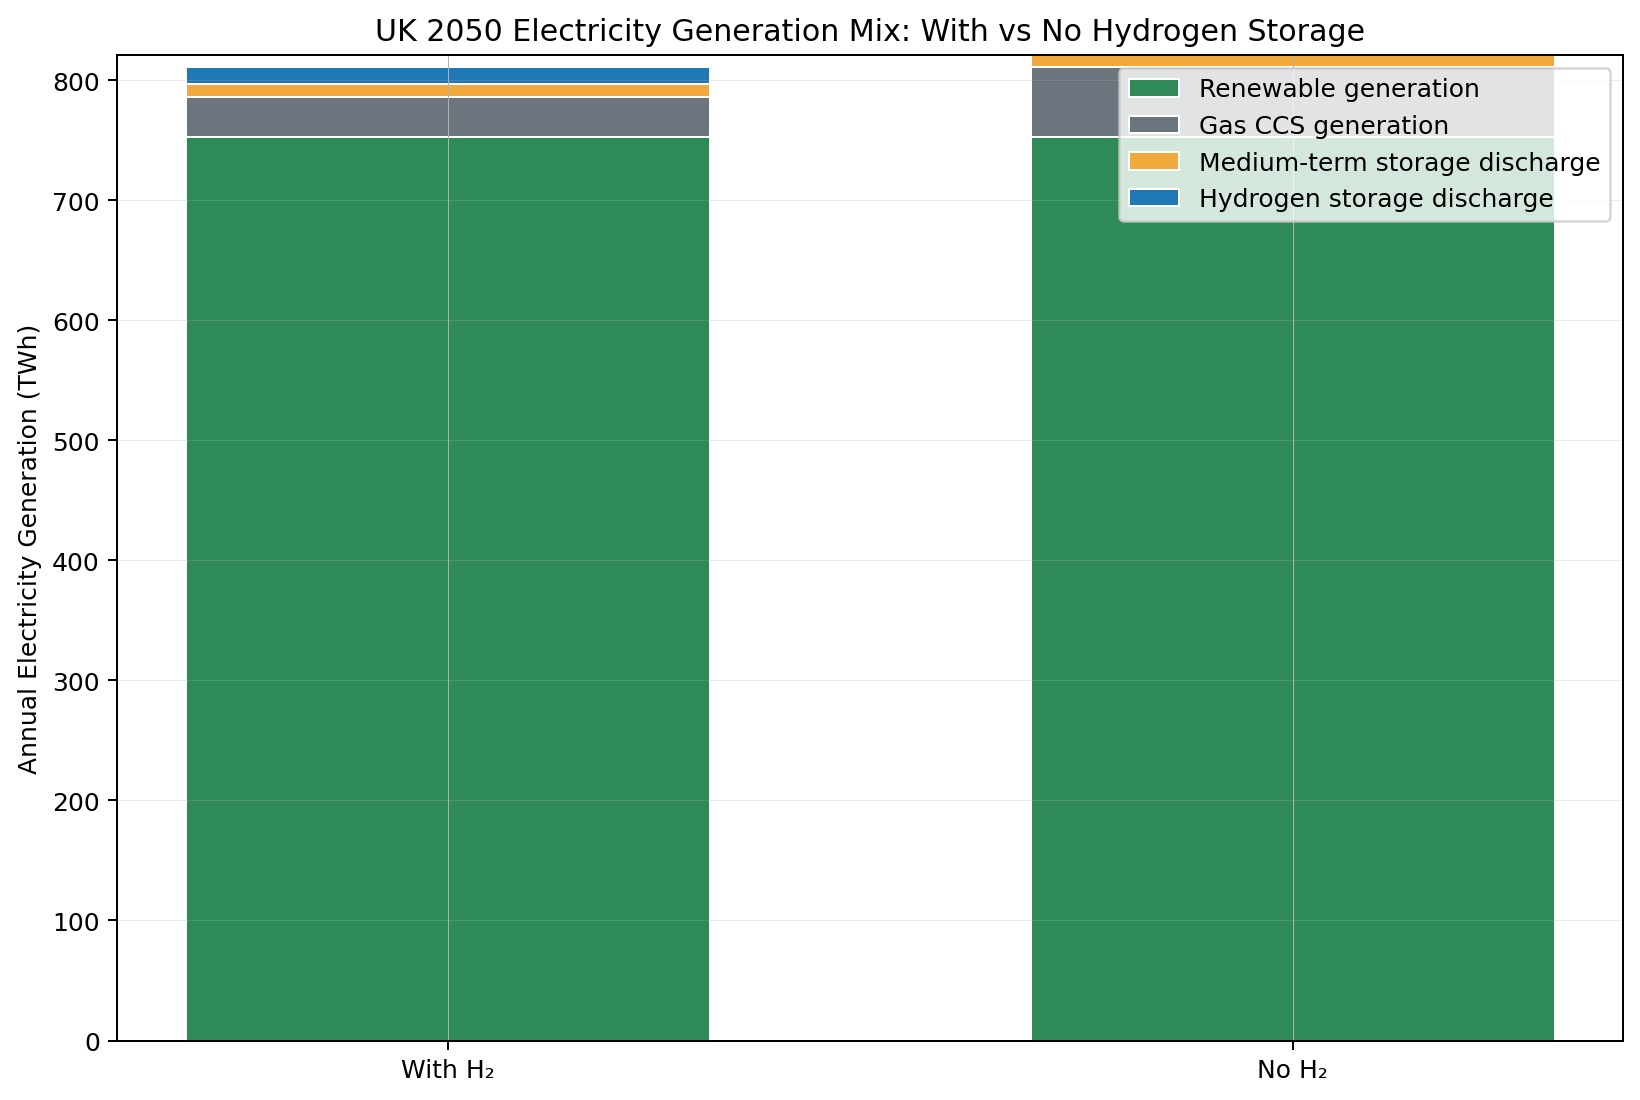

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.supply_model import daily_renewables_capacity


def _col(sim_df: pd.DataFrame, name: str) -> pd.Series:
    col = f"{name} (TWh),RC={REN_GW}GW"
    return pd.Series(sim_df[col].pint.magnitude, index=sim_df.index)


def _to_twh_scalar(x) -> float:
    return float(x.to(U.TWh).magnitude) if hasattr(x, "to") else float(x)


def _annual_medium_discharge_twh(sim_df: pd.DataFrame, ps) -> float:
    level = _col(sim_df, "medium_storage_level")
    charge_in = _col(sim_df, "energy_into_medium_storage")
    prev_level = level.shift(1).fillna(ps.initial_medium_storage_level)
    eff = ps.medium_storage_efficiency
    # level_t = level_{t-1} + charge*eff - discharge/eff
    discharge = ((prev_level + charge_in * eff - level) * eff).clip(lower=0)
    return float(discharge.mean() * 365)


def _annual_h2_discharge_twh(sim_df: pd.DataFrame, ps) -> float:
    level = _col(sim_df, "hydrogen_storage_level")
    charge_in = _col(sim_df, "energy_into_hydrogen_storage")
    prev_level = level.shift(1).fillna(ps.initial_hydrogen_storage_level)
    e_in = ps.hydrogen_e_in
    e_out = ps.hydrogen_e_out
    # level_t = level_{t-1} + charge*e_in - discharge/e_out
    discharge = ((prev_level + charge_in * e_in - level) * e_out).clip(lower=0)
    return float(discharge.mean() * 365)


# Annual generation components (TWh)
annual_renewable_twh = _to_twh_scalar(daily_renewables_capacity(REN_GW * U.GW, daily_cf).mean() * 365)
annual_gas_h2_twh = _to_twh_scalar(analysis_h2["annual_gas_ccs_energy"])
annual_gas_no_twh = _to_twh_scalar(analysis_no_h2["annual_gas_ccs_energy"])
annual_medium_h2_twh = _annual_medium_discharge_twh(sim_h2, ps_h2)
annual_medium_no_twh = _annual_medium_discharge_twh(sim_no_h2, ps_no_h2)
annual_h2_discharge_twh = _annual_h2_discharge_twh(sim_h2, ps_h2)

scenarios = ["With H₂", "No H₂"]
x = np.arange(len(scenarios))
width = 0.62

mix = {
    "Renewable generation": [annual_renewable_twh, annual_renewable_twh],  # same by construction
    "Gas CCS generation": [annual_gas_h2_twh, annual_gas_no_twh],
    "Medium-term storage discharge": [annual_medium_h2_twh, annual_medium_no_twh],
    "Hydrogen storage discharge": [annual_h2_discharge_twh, 0.0],
}
colors = {
    "Renewable generation": "#2E8B57",
    "Gas CCS generation": "#6C757D",
    "Medium-term storage discharge": "#F2A93B",
    "Hydrogen storage discharge": "#1F77B4",
}

fig, ax = plt.subplots(figsize=(9, 6), dpi=180)
bottom = np.zeros(len(scenarios), dtype=float)

for k in ["Renewable generation", "Gas CCS generation", "Medium-term storage discharge", "Hydrogen storage discharge"]:
    vals = np.array(mix[k], dtype=float)
    ax.bar(x, vals, width, bottom=bottom, label=k, color=colors[k], edgecolor="white", linewidth=0.8)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel("Annual Electricity Generation (TWh)")
ax.set_title("UK 2050 Electricity Generation Mix: With vs No Hydrogen Storage")
ax.legend(frameon=True, loc="upper right")
ax.grid(axis="y", alpha=0.25)
plt.show()


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_42424\4030212180.py:51: UserWarning:

The figure layout has changed to tight



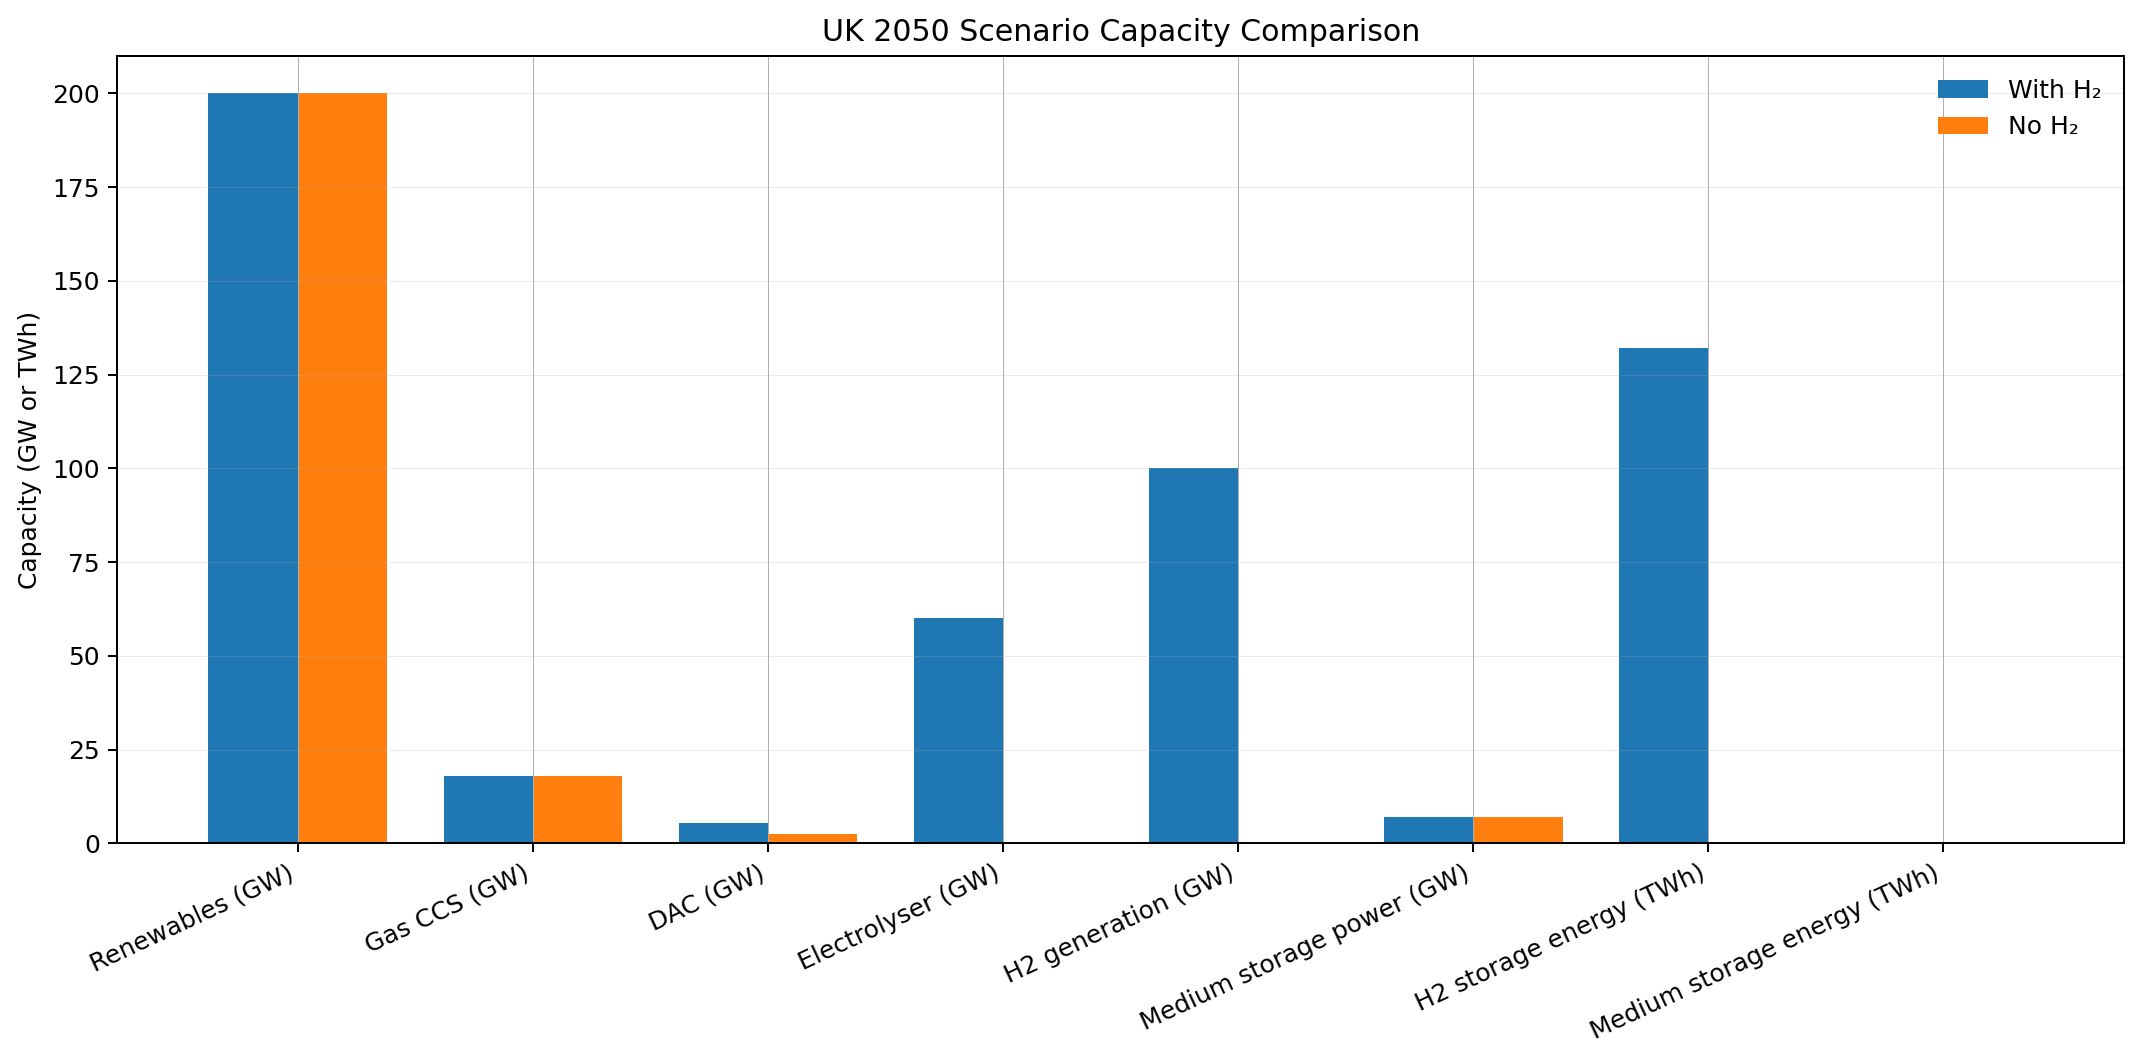

In [34]:
import matplotlib.pyplot as plt
import numpy as np

labels = [
    "Renewables (GW)",
    "Gas CCS (GW)",
    "DAC (GW)",
    "Electrolyser (GW)",
    "H2 generation (GW)",
    "Medium storage power (GW)",
    "H2 storage energy (TWh)",
    "Medium storage energy (TWh)",
]

with_h2_vals = [
    float(ps_h2.renewable_capacity),
    float(ps_h2.gas_ccs_capacity),
    float(ps_h2.dac_capacity),
    float(ps_h2.electrolyser_power),
    float(ps_h2.hydrogen_generation_power),
    float(ps_h2.medium_storage_power),
    float(ps_h2.hydrogen_storage_capacity),
    float(ps_h2.medium_storage_capacity),
]

no_h2_vals = [
    float(ps_no_h2.renewable_capacity),
    float(ps_no_h2.gas_ccs_capacity),
    float(ps_no_h2.dac_capacity),
    0.0,  # no electrolyser in no_h2 model
    0.0,  # no H2 generation in no_h2 model
    float(ps_no_h2.medium_storage_power),
    0.0,  # no H2 storage in no_h2 model
    float(ps_no_h2.medium_storage_capacity),
]

x = np.arange(len(labels))
w = 0.38

fig, ax = plt.subplots(figsize=(12, 6), dpi=180)
ax.bar(x - w / 2, with_h2_vals, width=w, label="With H₂", color="#1F77B4")
ax.bar(x + w / 2, no_h2_vals, width=w, label="No H₂", color="#FF7F0E")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Capacity (GW or TWh)")
ax.set_title("UK 2050 Scenario Capacity Comparison")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_42424\604231995.py:137: UserWarning:

The figure layout has changed to tight



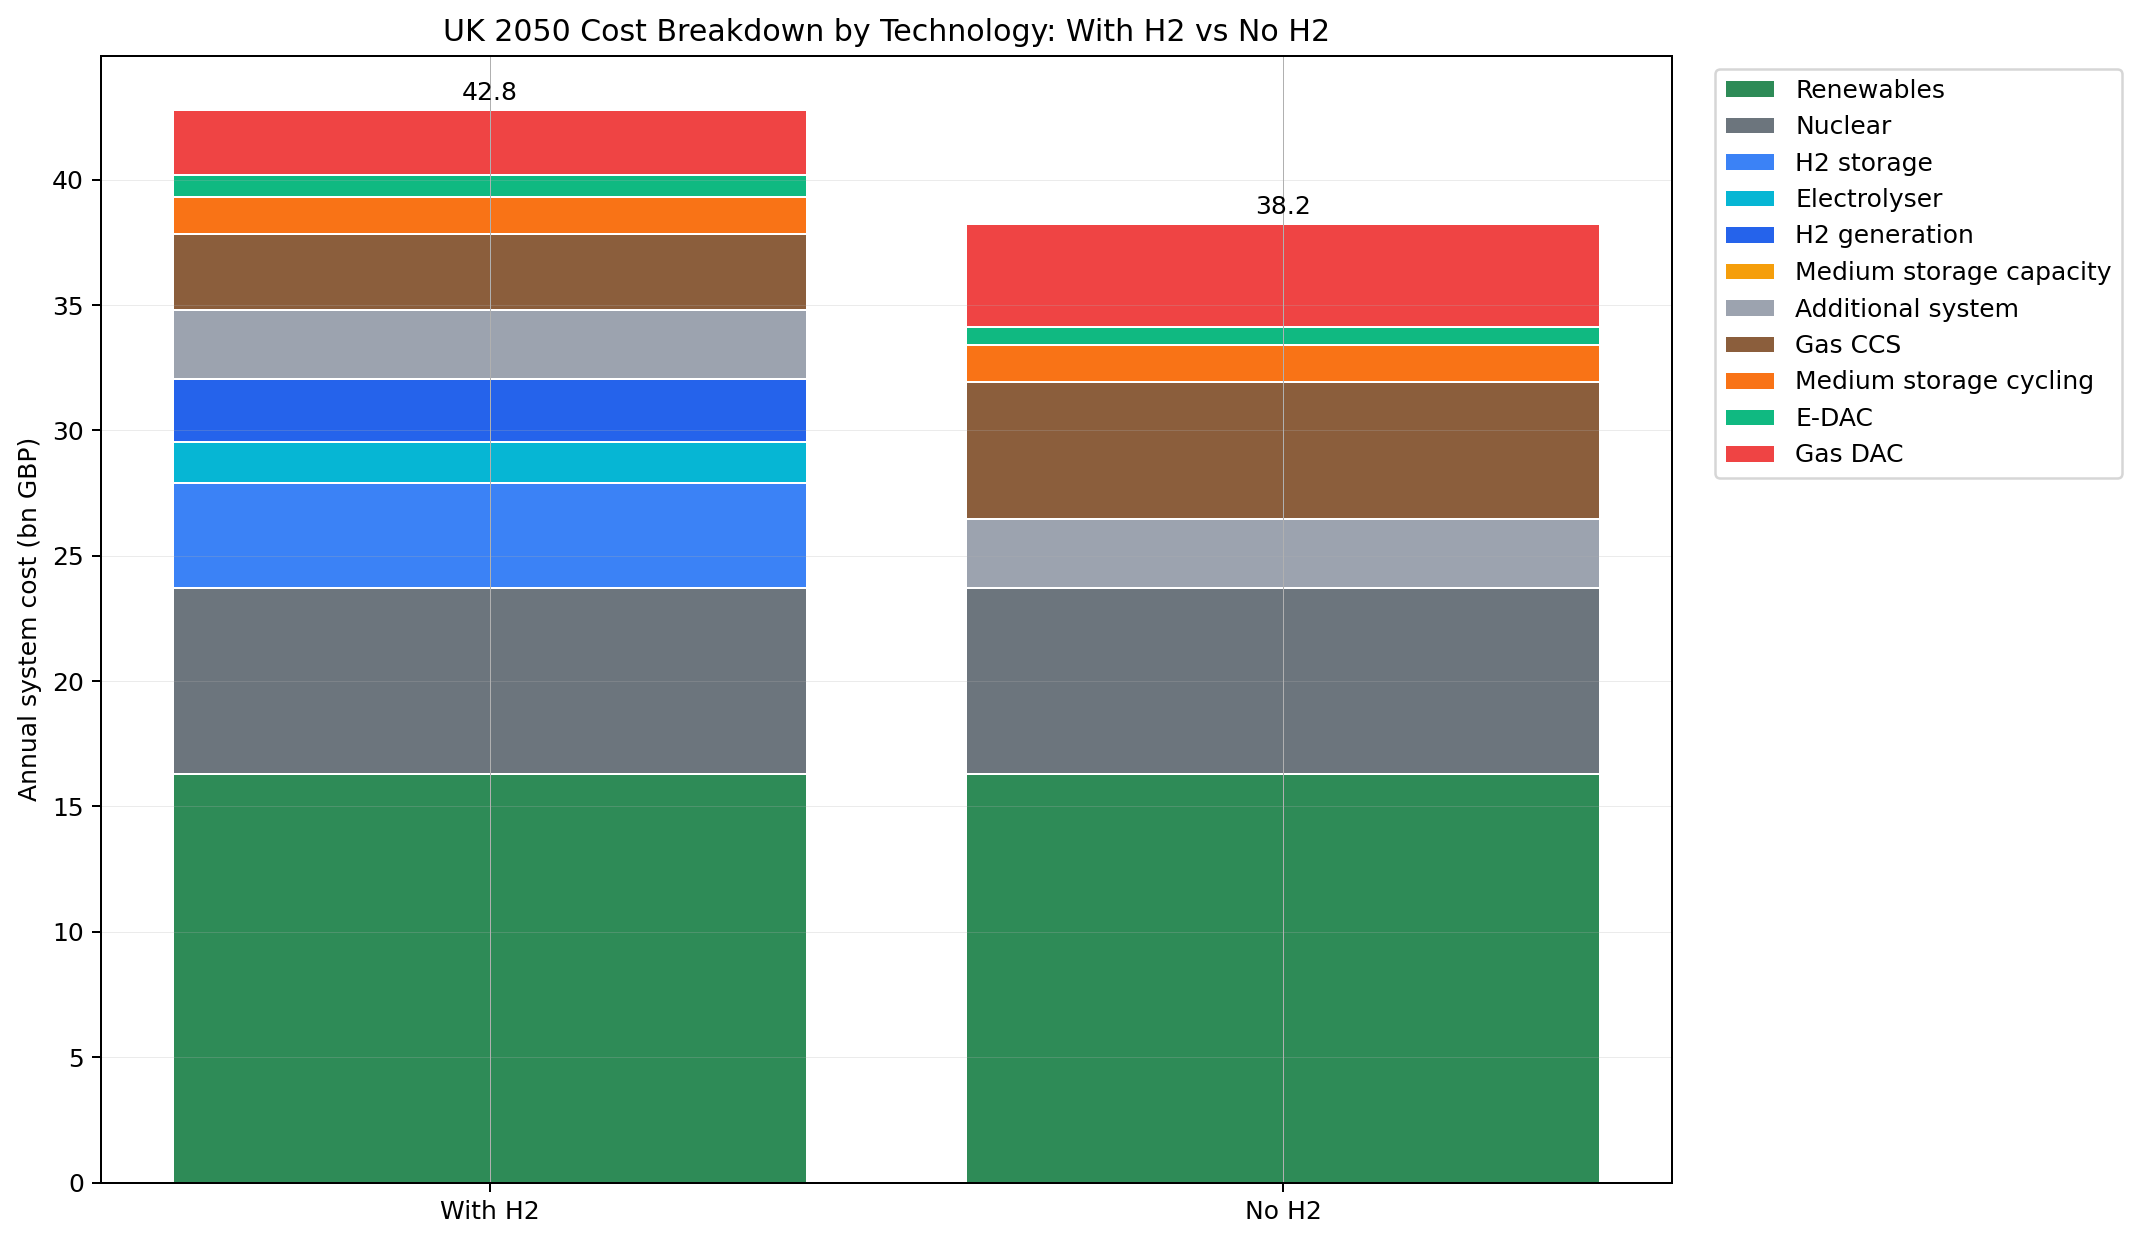

,Renewables,Nuclear,H2 storage,Electrolyser,H2 generation,Medium storage capacity,Additional system,Gas CCS,Medium storage cycling,E-DAC,Gas DAC
With H2,16.31,7.38,4.23,1.6,2.52,0.00,2.77,3.03,1.49,0.88,2.60
No H2,16.31,7.38,0.00,0.0,0.00,0.01,2.77,5.46,1.49,0.70,4.09


In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import src.assumptions as A
from src.power_system import PowerSystem
from src.power_system_no_h2 import PowerSystemNoH2
from src.units import Units as U


def _to_gbp_bn(value):
    return float(value.to(U.GBP).magnitude) / 1e9


def technology_cost_breakdown(ps, sim_df):
    rc = int(ps.renewable_capacity)
    gas_ccs_col = f"gas_ccs_energy (TWh),RC={rc}GW"
    gas_dac_elec_col = f"gas_dac_electricity (TWh),RC={rc}GW"
    medium_storage_col = f"energy_into_medium_storage (TWh),RC={rc}GW"
    dac_col = f"dac_energy (TWh),RC={rc}GW"
    gas_dac_capture_col = f"gas_dac_capture (MtCO2),RC={rc}GW"

    gas_dac_electricity = 0 * U.TWh
    if gas_dac_elec_col in sim_df.columns:
        gas_dac_electricity = sim_df[gas_dac_elec_col].mean() * 365

    costs = {
        "Renewables": yearly_cost(
            capacity=ps.renewable_capacity * U.GW,
            capacity_factor=A.Renewables.AverageCapacityFactor,
            lcoe=A.Renewables.AverageLCOE,
        ),
        "Nuclear": yearly_cost(
            capacity=A.Nuclear.Capacity,
            capacity_factor=A.Nuclear.CapacityFactor,
            lcoe=A.Nuclear.AverageLCOE,
        ),
        "H2 storage": 0 * U.GBP,
        "Electrolyser": 0 * U.GBP,
        "H2 generation": 0 * U.GBP,
        "Medium storage capacity": 0 * U.GBP,
        "Additional system": (A.AdditionalCosts * A.EnergyDemand2050).to(U.GBP),
        "Gas CCS": ((sim_df[gas_ccs_col].mean() * 365) - gas_dac_electricity) * A.DispatchableGasCCS.LCOE,
        "Medium storage cycling": (sim_df[medium_storage_col].mean() * 365) * A.MediumTermStorage.LCOE,
        "E-DAC": (sim_df[dac_col].mean() * 365) * A.EDAC.LCOE,
        "Gas DAC": 0 * U.GBP,
    }

    if isinstance(ps, PowerSystem):
        costs["H2 storage"] = (
            ps.hydrogen_storage_capacity * U.TWh * A.HydrogenStorage.CavernStorage.AnnualisedCost
        ).to(U.GBP)
        costs["Electrolyser"] = (
            ps.electrolyser_power * U.GW * A.HydrogenStorage.Electrolysis.AnnualisedCost
        ).to(U.GBP)
        costs["H2 generation"] = (
            ps.hydrogen_generation_power * U.GW * A.HydrogenStorage.Generation.AnnualisedCost
        ).to(U.GBP)
    elif isinstance(ps, PowerSystemNoH2):
        costs["Medium storage capacity"] = (
            ps.medium_storage_capacity * U.TWh * A.HydrogenStorage.CavernStorage.AnnualisedCost
        ).to(U.GBP)
    else:
        raise TypeError(f"Unsupported power system type: {type(ps)}")

    if gas_dac_capture_col in sim_df.columns:
        annual_gas_dac_capture = sim_df[gas_dac_capture_col].mean() * 365
        gas_dac_electricity_emissions = (
            gas_dac_electricity.to(U.MWh) * A.GasTechDACParameters.GasCO2Intensity
        ).to(U.t)
        net_gas_dac_capture = annual_gas_dac_capture.to(U.t) - gas_dac_electricity_emissions
        costs["Gas DAC"] = (net_gas_dac_capture * A.LTDAC.LCOR).to(U.GBP)

    return costs


tech_order = [
    "Renewables",
    "Nuclear",
    "H2 storage",
    "Electrolyser",
    "H2 generation",
    "Medium storage capacity",
    "Additional system",
    "Gas CCS",
    "Medium storage cycling",
    "E-DAC",
    "Gas DAC",
]

tech_colors = {
    "Renewables": "#2E8B57",
    "Nuclear": "#6C757D",
    "H2 storage": "#3B82F6",
    "Electrolyser": "#06B6D4",
    "H2 generation": "#2563EB",
    "Medium storage capacity": "#F59E0B",
    "Additional system": "#9CA3AF",
    "Gas CCS": "#8B5E3C",
    "Medium storage cycling": "#F97316",
    "E-DAC": "#10B981",
    "Gas DAC": "#EF4444",
}

cost_breakdown_bn = pd.DataFrame(
    {
        "With H2": {k: _to_gbp_bn(v) for k, v in technology_cost_breakdown(ps_h2, sim_h2).items()},
        "No H2": {k: _to_gbp_bn(v) for k, v in technology_cost_breakdown(ps_no_h2, sim_no_h2).items()},
    }
).T[tech_order]

fig, ax = plt.subplots(figsize=(12, 7), dpi=180)
bottom = np.zeros(len(cost_breakdown_bn), dtype=float)

for tech in tech_order:
    values = cost_breakdown_bn[tech].to_numpy(dtype=float)
    ax.bar(
        cost_breakdown_bn.index,
        values,
        bottom=bottom,
        label=tech,
        color=tech_colors[tech],
        edgecolor="white",
        linewidth=0.8,
    )
    bottom += values

for i, total in enumerate(cost_breakdown_bn.sum(axis=1).to_numpy(dtype=float)):
    ax.text(i, total + 0.2, f"{total:.1f}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Annual system cost (bn GBP)")
ax.set_title("UK 2050 Cost Breakdown by Technology: With H2 vs No H2")
ax.grid(axis="y", alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_DIR / "cost_breakdown_by_technology.png", bbox_inches="tight")
plt.show()

cost_breakdown_bn.round(2)


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_42424\1737543923.py:146: UserWarning:

This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.



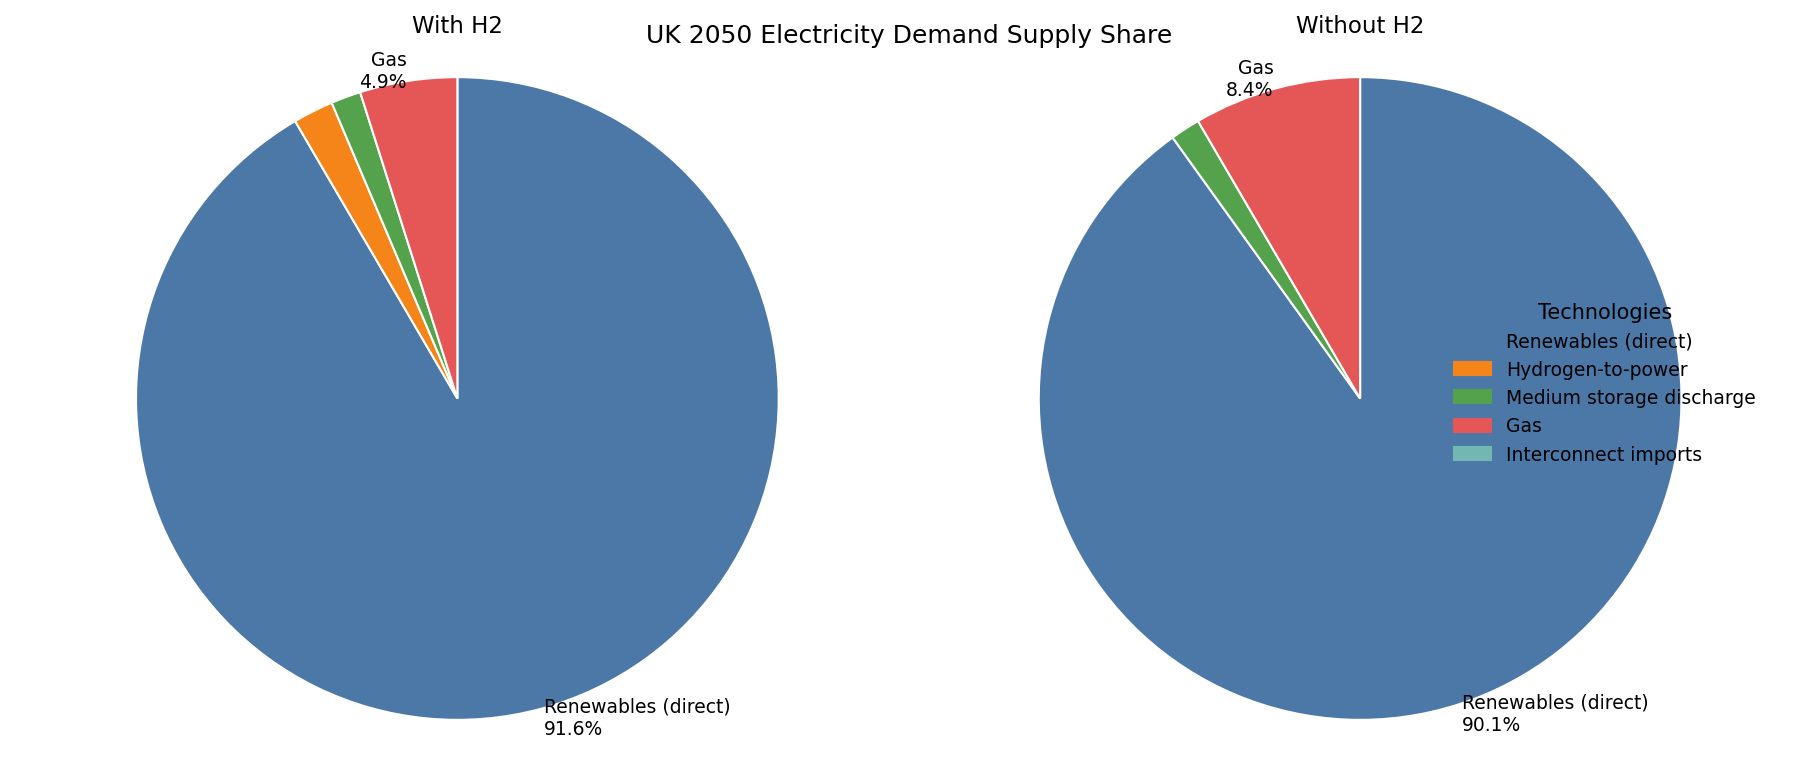

,with_h2_twh,with_h2_%,without_h2_twh,without_h2_%
Renewables (direct),633.71,91.58,623.38,90.08
Hydrogen-to-power,14.04,2.03,0.00,0.00
Medium storage discharge,10.40,1.50,10.40,1.50
Gas,33.85,4.89,58.22,8.41
Interconnect imports,0.00,0.00,0.00,0.00


In [36]:
# Full cell: 2 pie charts (with H2 / without H2), aligned colors, small pies, no title overlap
# Assumes these already exist in your notebook:
# ps_h2, sim_h2, ps_no_h2, sim_no_h2

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

import src.assumptions as A
from src.units import Units as U

# ---------- safety check ----------
for _v in ["ps_h2", "sim_h2", "ps_no_h2", "sim_no_h2"]:
    if _v not in globals():
        raise NameError(f"'{_v}' not found. Run the simulation cells first.")

if sim_h2 is None or sim_no_h2 is None:
    raise RuntimeError("One simulation failed (sim_h2 or sim_no_h2 is None).")


# ---------- helpers ----------
def _find_col(df, prefix: str):
    for c in df.columns:
        if str(c).startswith(prefix):
            return c
    return None


def _annual_mean_twh(series) -> float:
    return float((series.astype("pint[TWh]").mean() * 365).to(U.TWh).magnitude)


def _annual_medium_discharge_twh(sim_df, ps) -> float:
    col = _find_col(sim_df, "medium_storage_level (TWh),RC=")
    if col is None:
        return 0.0
    level = sim_df[col].astype("pint[TWh]")
    start = ps.initial_medium_storage_level * U.TWh
    drawn = (level.shift(1, fill_value=start) - level).clip(lower=0 * U.TWh)
    discharged = drawn * ps.medium_storage_efficiency
    return float((discharged.mean() * 365).to(U.TWh).magnitude)


def _annual_h2_discharge_twh(sim_df, ps) -> float:
    col = _find_col(sim_df, "hydrogen_storage_level (TWh),RC=")
    if col is None or not hasattr(ps, "hydrogen_e_out"):
        return 0.0
    level = sim_df[col].astype("pint[TWh]")
    start = ps.initial_hydrogen_storage_level * U.TWh
    drawn = (level.shift(1, fill_value=start) - level).clip(lower=0 * U.TWh)
    discharged = drawn * ps.hydrogen_e_out
    return float((discharged.mean() * 365).to(U.TWh).magnitude)


def _contrib_twh(ps, sim_df) -> pd.Series:
    annual_demand = float(A.EnergyDemand2050.to(U.TWh).magnitude)

    gas_col = _find_col(sim_df, "gas_ccs_energy (TWh),RC=")
    inter_col = _find_col(sim_df, "interconnect_energy (TWh),RC=")

    gas = _annual_mean_twh(sim_df[gas_col]) if gas_col else 0.0
    inter = _annual_mean_twh(sim_df[inter_col]) if inter_col else 0.0
    medium = _annual_medium_discharge_twh(sim_df, ps)
    h2 = _annual_h2_discharge_twh(sim_df, ps)

    renew_direct = annual_demand - gas - inter - medium - h2
    if abs(renew_direct) < 1e-9:
        renew_direct = 0.0

    return pd.Series({
        "Renewables (direct)": renew_direct,
        "Hydrogen-to-power": h2,
        "Medium storage discharge": medium,
        "Gas": gas,
        "Interconnect imports": inter,
    })


# ---------- fixed order + fixed colors (aligned across charts) ----------
TECH_ORDER = [
    "Renewables (direct)",
    "Hydrogen-to-power",
    "Medium storage discharge",
    "Gas",
    "Interconnect imports",
]

TECH_COLORS = {
    "Renewables (direct)": "#4C78A8",        # blue
    "Hydrogen-to-power": "#F58518",          # orange
    "Medium storage discharge": "#54A24B",   # green
    "Gas": "#E45756",                  # red
    "Interconnect imports": "#72B7B2",       # teal
}

annual_demand_twh = float(A.EnergyDemand2050.to(U.TWh).magnitude)

c_with = _contrib_twh(ps_h2, sim_h2).reindex(TECH_ORDER, fill_value=0.0)
c_no = _contrib_twh(ps_no_h2, sim_no_h2).reindex(TECH_ORDER, fill_value=0.0)

# ---------- plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
LABEL_THRESHOLD = 3.0  # show on-slice text only for >= 3%

for ax, title, contrib in [
    (axes[0], "With H2", c_with),
    (axes[1], "Without H2", c_no),
]:
    pct = 100 * contrib / annual_demand_twh

    # only non-zero slices
    mask = contrib > 1e-6
    vals = contrib[mask]
    pcts = pct[mask]
    colors = [TECH_COLORS[t] for t in vals.index]

    labels = [
        f"{t}\n{p:.1f}%" if p >= LABEL_THRESHOLD else ""
        for t, p in zip(vals.index, pcts, strict=False)
    ]

    ax.pie(
        vals.values,
        labels=labels,
        colors=colors,
        startangle=90,
        counterclock=False,
        radius=0.58,                 # small pies
        center=(0, -0.12),           # move down to avoid title overlap
        labeldistance=1.03,
        wedgeprops={"edgecolor": "white", "linewidth": 1},
        textprops={"fontsize": 9},
    )
    ax.set_title(title, fontsize=11, pad=6)
    ax.axis("equal")

# shared legend with fixed color mapping
legend_handles = [mpatches.Patch(color=TECH_COLORS[t], label=t) for t in TECH_ORDER]
fig.legend(
    handles=legend_handles,
    loc="center right",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False,
    title="Technologies",
    fontsize=9,
    title_fontsize=10,
)

fig.suptitle("UK 2050 Electricity Demand Supply Share", fontsize=12, y=0.98)

# no tight_layout()
fig.subplots_adjust(left=0.05, right=0.82, bottom=0.08, top=0.70, wspace=0.45)
plt.show()

# Optional: table
display(pd.DataFrame({
    "with_h2_twh": c_with,
    "with_h2_%": (100 * c_with / annual_demand_twh),
    "without_h2_twh": c_no,
    "without_h2_%": (100 * c_no / annual_demand_twh),
}).round(2))


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_42424\2540998779.py:161: UserWarning:

This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.



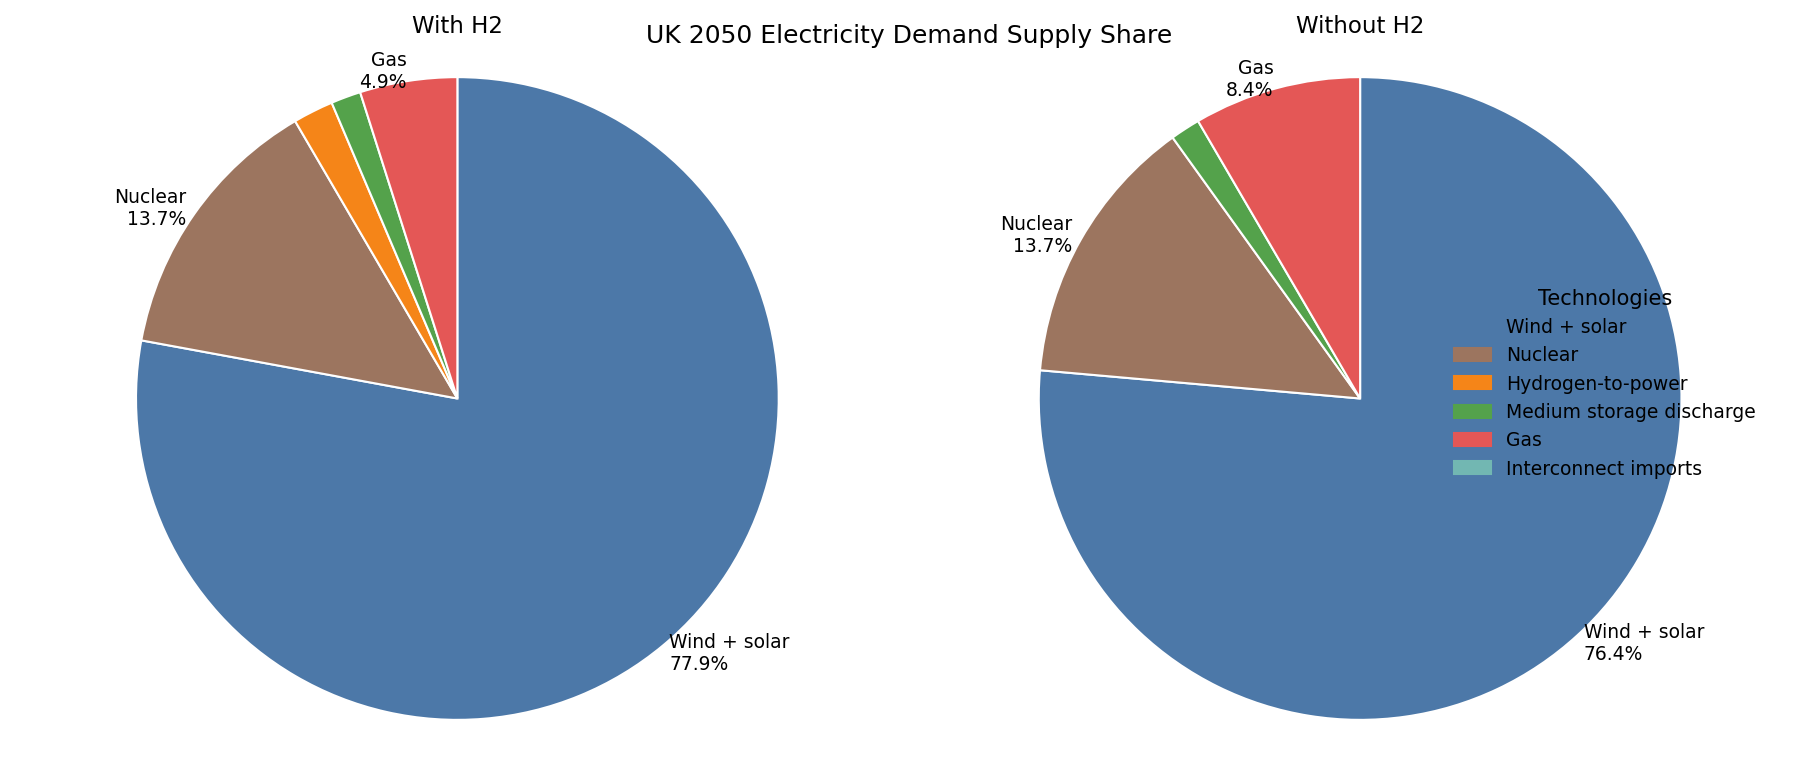

,with_h2_twh,with_h2_%,without_h2_twh,without_h2_%
Wind + solar,539.04,77.90,528.70,76.40
Nuclear,94.67,13.68,94.67,13.68
Hydrogen-to-power,14.04,2.03,0.00,0.00
Medium storage discharge,10.40,1.50,10.40,1.50
Gas,33.85,4.89,58.22,8.41
Interconnect imports,0.00,0.00,0.00,0.00


In [37]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

import src.assumptions as A
from src.units import Units as U

# Assumes these already exist:
# ps_h2, sim_h2, ps_no_h2, sim_no_h2

for _v in ["ps_h2", "sim_h2", "ps_no_h2", "sim_no_h2"]:
    if _v not in globals():
        raise NameError(f"'{_v}' not found. Run the simulation cells first.")

if sim_h2 is None or sim_no_h2 is None:
    raise RuntimeError("One simulation failed (sim_h2 or sim_no_h2 is None).")


def _find_col(df, prefix: str):
    for c in df.columns:
        if str(c).startswith(prefix):
            return c
    return None


def _annual_mean_twh(series) -> float:
    return float((series.astype("pint[TWh]").mean() * 365).to(U.TWh).magnitude)


def _annual_medium_discharge_twh(sim_df, ps) -> float:
    col_level = _find_col(sim_df, "medium_storage_level (TWh),RC=")
    col_charge = _find_col(sim_df, "energy_into_medium_storage (TWh),RC=")
    if col_level is None or col_charge is None:
        return 0.0

    level = pd.Series(sim_df[col_level].pint.magnitude, index=sim_df.index)
    charge_in = pd.Series(sim_df[col_charge].pint.magnitude, index=sim_df.index)
    prev_level = level.shift(1).fillna(ps.initial_medium_storage_level)
    eff = ps.medium_storage_efficiency

    # level_t = level_(t-1) + charge*eff - discharge/eff
    discharge = ((prev_level + charge_in * eff - level) * eff).clip(lower=0)
    return float(discharge.mean() * 365)


def _annual_h2_discharge_twh(sim_df, ps) -> float:
    col_level = _find_col(sim_df, "hydrogen_storage_level (TWh),RC=")
    col_charge = _find_col(sim_df, "energy_into_hydrogen_storage (TWh),RC=")
    if col_level is None or col_charge is None or not hasattr(ps, "hydrogen_e_out"):
        return 0.0

    level = pd.Series(sim_df[col_level].pint.magnitude, index=sim_df.index)
    charge_in = pd.Series(sim_df[col_charge].pint.magnitude, index=sim_df.index)
    prev_level = level.shift(1).fillna(ps.initial_hydrogen_storage_level)
    e_in = ps.hydrogen_e_in
    e_out = ps.hydrogen_e_out

    # level_t = level_(t-1) + charge*e_in - discharge/e_out
    discharge = ((prev_level + charge_in * e_in - level) * e_out).clip(lower=0)
    return float(discharge.mean() * 365)


def _annual_nuclear_twh() -> float:
    return float((A.Nuclear.Capacity * A.Nuclear.CapacityFactor * A.HoursPerYear).to(U.TWh).magnitude)


def _contrib_twh(ps, sim_df) -> pd.Series:
    annual_demand = float(A.EnergyDemand2050.to(U.TWh).magnitude)
    annual_nuclear = _annual_nuclear_twh()

    gas_col = _find_col(sim_df, "gas_ccs_energy (TWh),RC=")
    inter_col = _find_col(sim_df, "interconnect_energy (TWh),RC=")

    gas = _annual_mean_twh(sim_df[gas_col]) if gas_col else 0.0
    inter = _annual_mean_twh(sim_df[inter_col]) if inter_col else 0.0
    medium = _annual_medium_discharge_twh(sim_df, ps)
    h2 = _annual_h2_discharge_twh(sim_df, ps)

    renewables_direct = annual_demand - annual_nuclear - gas - inter - medium - h2
    if abs(renewables_direct) < 1e-9:
        renewables_direct = 0.0

    return pd.Series({
        "Wind + solar": renewables_direct,
        "Nuclear": annual_nuclear,
        "Hydrogen-to-power": h2,
        "Medium storage discharge": medium,
        "Gas": gas,
        "Interconnect imports": inter,
    })


TECH_ORDER = [
    "Wind + solar",
    "Nuclear",
    "Hydrogen-to-power",
    "Medium storage discharge",
    "Gas",
    "Interconnect imports",
]

TECH_COLORS = {
    "Wind + solar": "#4C78A8",
    "Nuclear": "#9C755F",
    "Hydrogen-to-power": "#F58518",
    "Medium storage discharge": "#54A24B",
    "Gas": "#E45756",
    "Interconnect imports": "#72B7B2",
}

annual_demand_twh = float(A.EnergyDemand2050.to(U.TWh).magnitude)

c_with = _contrib_twh(ps_h2, sim_h2).reindex(TECH_ORDER, fill_value=0.0)
c_no = _contrib_twh(ps_no_h2, sim_no_h2).reindex(TECH_ORDER, fill_value=0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
LABEL_THRESHOLD = 3.0

for ax, title, contrib in [
    (axes[0], "With H2", c_with),
    (axes[1], "Without H2", c_no),
]:
    pct = 100 * contrib / annual_demand_twh
    mask = contrib > 1e-6
    vals = contrib[mask]
    pcts = pct[mask]
    colors = [TECH_COLORS[t] for t in vals.index]

    labels = [
        f"{t}\n{p:.1f}%" if p >= LABEL_THRESHOLD else ""
        for t, p in zip(vals.index, pcts, strict=False)
    ]

    ax.pie(
        vals.values,
        labels=labels,
        colors=colors,
        startangle=90,
        counterclock=False,
        radius=0.58,
        center=(0, -0.12),
        labeldistance=1.03,
        wedgeprops={"edgecolor": "white", "linewidth": 1},
        textprops={"fontsize": 9},
    )
    ax.set_title(title, fontsize=11, pad=6)
    ax.axis("equal")

legend_handles = [mpatches.Patch(color=TECH_COLORS[t], label=t) for t in TECH_ORDER]
fig.legend(
    handles=legend_handles,
    loc="center right",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False,
    title="Technologies",
    fontsize=9,
    title_fontsize=10,
)

fig.suptitle("UK 2050 Electricity Demand Supply Share", fontsize=12, y=0.98)
fig.subplots_adjust(left=0.05, right=0.82, bottom=0.08, top=0.70, wspace=0.45)
plt.show()

display(pd.DataFrame({
    "with_h2_twh": c_with,
    "with_h2_%": 100 * c_with / annual_demand_twh,
    "without_h2_twh": c_no,
    "without_h2_%": 100 * c_no / annual_demand_twh,
}).round(2))